In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(486)_aug3.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(251)_aug3.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(343)_aug1.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(84)_aug2.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(99)_aug3.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(21)_aug4.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(25)_aug4.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(469)_aug3.jpg
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data/Metal/Metal(406)_aug1.

In [2]:
import os

project_dir = "/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset"

os.makedirs(project_dir, exist_ok=True)

print("Created:", project_dir)

Created: /kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset


In [3]:
from pathlib import Path

yaml_files = list(Path("/kaggle/input").rglob("data.yaml"))

print("Found data.yaml files:")
for f in yaml_files:
    print(f)

Found data.yaml files:
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data/E-Waste Dataset/data.yaml


In [4]:
for yaml_file in yaml_files:
    print("\n" + "=" * 80)
    print(yaml_file)
    print("=" * 80)

    with open(yaml_file, "r", encoding="utf-8") as f:
        print(f.read())


/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data/E-Waste Dataset/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 12
names: ['Battery_Waste', 'Glass_Waste', 'Keyboard', 'Light_Bulb', 'Medical_Waste', 'Metal_Waste', 'Mobile', 'Mouse', 'Organic_Waste', 'PCB', 'Paper_Waste', 'Plastic_Waste']

roboflow:
  workspace: azizul-abedin-azmi-uwbiw
  project: e-waste-uvzkj
  version: 5
  license: CC BY 4.0
  url: https://universe.roboflow.com/azizul-abedin-azmi-uwbiw/e-waste-uvzkj/dataset/5


In [5]:
from pathlib import Path
from collections import Counter
import yaml

# নিজের actual data.yaml path automatically find
yaml_file = next(
    p for p in Path("/kaggle/input").rglob("data.yaml")
    if "e-waste" in str(p).lower() or "ewaste" in str(p).lower()
)

with open(yaml_file, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

print("Classes:")
print(data.get("names"))

Classes:
['Battery_Waste', 'Glass_Waste', 'Keyboard', 'Light_Bulb', 'Medical_Waste', 'Metal_Waste', 'Mobile', 'Mouse', 'Organic_Waste', 'PCB', 'Paper_Waste', 'Plastic_Waste']


In [6]:
dataset_root = yaml_file.parent

counter = Counter()

for split in ["train", "valid", "val", "test"]:
    label_dir = dataset_root / split / "labels"

    if not label_dir.exists():
        continue

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                class_id = int(line.split()[0])
                counter[class_id] += 1

print("\nYOLO object/class distribution:")

names = data.get("names", {})

for class_id, count in sorted(counter.items()):
    if isinstance(names, list):
        class_name = names[class_id]
    else:
        class_name = names.get(class_id, names.get(str(class_id), "UNKNOWN"))

    print(f"{class_id:>3} → {class_name:<30} {count:,}")


YOLO object/class distribution:
  0 → Battery_Waste                  154
  1 → Glass_Waste                    127
  2 → Keyboard                       126
  3 → Light_Bulb                     43
  4 → Medical_Waste                  282
  5 → Metal_Waste                    293
  6 → Mobile                         151
  7 → Mouse                          80
  8 → Organic_Waste                  100
  9 → PCB                            205
 10 → Paper_Waste                    200
 11 → Plastic_Waste                  398


In [7]:
CLASS_MAPPING = {
    # Bangladesh
    "paper waste": "Paper",
    "plastic waste": "Plastic",
    "glass waste": "Glass",
    "metal waste": "Metal",
    "cardboard": "Cardboard",

    # International
    "paper": "Paper",
    "plastic": "Plastic",
    "glass": "Glass",
    "metal": "Metal",
    "cardboard": "Cardboard",
}

In [8]:
import os

print("=== /kaggle/input ===")

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    
    if level <= 3:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        
        for file in files[:10]:
            print(f"{indent}  {file}")

=== /kaggle/input ===
input/
  datasets/
    kbmhkhan/
      waste-classification/


In [9]:
from pathlib import Path
from collections import Counter

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

def count_images(folder):
    folder = Path(folder)
    
    if not folder.exists():
        print(f"❌ Not found: {folder}")
        return
    
    counter = Counter()
    
    for file in folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
            relative = file.relative_to(folder)
            parts = relative.parts
            
            if len(parts) > 1:
                class_name = parts[0]
            else:
                class_name = "ROOT"
            
            counter[class_name] += 1
    
    print(f"\n📁 {folder}")
    
    for cls, count in sorted(counter.items()):
        print(f"   {cls}: {count}")


In [10]:
count_images("/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data")
count_images("/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data")


📁 /kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data
   Cardboard: 1648
   Glass: 1680
   Metal: 2040
   Paper: 2000
   Plastic: 1224

📁 /kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data
   A_waste management dataset: 907
   BDWaste: 494
   Cardboard: 73
   E-Waste Dataset: 2157


In [11]:
from pathlib import Path
from PIL import Image
from collections import Counter
import yaml
import shutil

# ============================================================
# 1. FIND E-WASTE DATASET
# ============================================================

yaml_file = next(
    p for p in Path("/kaggle/input").rglob("data.yaml")
    if "e-waste" in str(p).lower() or "ewaste" in str(p).lower()
)

dataset_root = yaml_file.parent

with open(yaml_file, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

print("Dataset:", dataset_root)
print("Classes:", class_names)


# ============================================================
# 2. MAPPING
# ============================================================

target_mapping = {
    1: "Glass",      # Glass_Waste
    5: "Metal",      # Metal_Waste
    10: "Paper",     # Paper_Waste
    11: "Plastic"    # Plastic_Waste
}

print("\nSelected classes:")
for class_id, final_class in target_mapping.items():
    print(f"{class_id} → {class_names[class_id]} → {final_class}")


# ============================================================
# 3. OUTPUT DIRECTORY
# ============================================================

output_root = Path("/kaggle/working/EWaste_5Class_Crops")

for class_name in target_mapping.values():
    (output_root / class_name).mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 4. PROCESS TRAIN / VALID / TEST
# ============================================================

split_mapping = {
    "train": "train",
    "valid": "valid",
    "test": "test"
}

stats = Counter()
failed = []

for split, split_name in split_mapping.items():

    image_dir = dataset_root / split / "images"
    label_dir = dataset_root / split / "labels"

    if not image_dir.exists():
        print(f"Skipping missing image directory: {image_dir}")
        continue

    if not label_dir.exists():
        print(f"Skipping missing label directory: {label_dir}")
        continue

    print(f"\nProcessing: {split.upper()}")

    image_files = []

    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        image_files.extend(image_dir.glob(ext))

    print("Images found:", len(image_files))

    for image_path in image_files:

        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            continue

        try:
            image = Image.open(image_path).convert("RGB")
            img_w, img_h = image.size

            with open(label_path, "r", encoding="utf-8") as f:
                lines = f.readlines()

            object_index = 0

            for line in lines:

                parts = line.strip().split()

                if len(parts) < 5:
                    continue

                class_id = int(parts[0])

                if class_id not in target_mapping:
                    continue

                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

                # YOLO normalized coordinates → pixels
                x_center *= img_w
                y_center *= img_h
                width *= img_w
                height *= img_h

                x1 = int(x_center - width / 2)
                y1 = int(y_center - height / 2)
                x2 = int(x_center + width / 2)
                y2 = int(y_center + height / 2)

                # Clamp coordinates
                x1 = max(0, min(x1, img_w - 1))
                y1 = max(0, min(y1, img_h - 1))
                x2 = max(x1 + 1, min(x2, img_w))
                y2 = max(y1 + 1, min(y2, img_h))

                crop = image.crop((x1, y1, x2, y2))

                final_class = target_mapping[class_id]

                output_name = (
                    f"{split_name}__"
                    f"{image_path.stem}__"
                    f"obj{object_index}.jpg"
                )

                output_path = (
                    output_root /
                    final_class /
                    output_name
                )

                crop.save(
                    output_path,
                    quality=95
                )

                stats[final_class] += 1
                object_index += 1

        except Exception as e:
            failed.append(
                (str(image_path), str(e))
            )

print("\n" + "=" * 70)
print("E-WASTE EXTRACTION COMPLETE")
print("=" * 70)

for class_name in ["Glass", "Metal", "Paper", "Plastic"]:
    print(
        f"{class_name:<10} : "
        f"{stats[class_name]:,}"
    )

print("\nFailed images:", len(failed))
print("Output:", output_root)

Dataset: /kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data/E-Waste Dataset
Classes: ['Battery_Waste', 'Glass_Waste', 'Keyboard', 'Light_Bulb', 'Medical_Waste', 'Metal_Waste', 'Mobile', 'Mouse', 'Organic_Waste', 'PCB', 'Paper_Waste', 'Plastic_Waste']

Selected classes:
1 → Glass_Waste → Glass
5 → Metal_Waste → Metal
10 → Paper_Waste → Paper
11 → Plastic_Waste → Plastic

Processing: TRAIN
Images found: 1500

Processing: VALID
Images found: 330

Processing: TEST
Images found: 327

E-WASTE EXTRACTION COMPLETE
Glass      : 127
Metal      : 293
Paper      : 200
Plastic    : 398

Failed images: 0
Output: /kaggle/working/EWaste_5Class_Crops


In [12]:
from pathlib import Path
from collections import Counter

root = Path("/kaggle/working/EWaste_5Class_Crops")

counts = {}

for class_dir in sorted(root.iterdir()):
    if class_dir.is_dir():
        counts[class_dir.name] = len(
            list(class_dir.glob("*.jpg"))
        )

print("E-Waste extracted dataset:")
print("-" * 40)

for cls, count in counts.items():
    print(f"{cls:<10} {count:,}")

E-Waste extracted dataset:
----------------------------------------
Glass      127
Metal      293
Paper      200
Plastic    398


# ********BDWASTE

In [13]:
from pathlib import Path

print("Possible BDWaste directories:\n")

for p in Path("/kaggle/input").rglob("*"):
    if "bdwaste" in p.name.lower():
        print(p)

Possible BDWaste directories:

/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data/BDWaste


In [14]:
from pathlib import Path

bdwaste_root = Path("/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data/BDWaste")

print("BDWaste structure:")
print("=" * 80)

for p in sorted(bdwaste_root.rglob("*")):
    relative = p.relative_to(bdwaste_root)

    if p.is_dir():
        print(f"[DIR ]  {relative}")
    else:
        print(f"[FILE]  {relative}")

BDWaste structure:
[DIR ]  Bottle
[FILE]  Bottle/1.jpg
[FILE]  Bottle/10.jpg
[FILE]  Bottle/100.jpg
[FILE]  Bottle/101.jpg
[FILE]  Bottle/102.jpg
[FILE]  Bottle/103.jpg
[FILE]  Bottle/104.jpg
[FILE]  Bottle/105.jpg
[FILE]  Bottle/106.jpg
[FILE]  Bottle/107.jpg
[FILE]  Bottle/108.jpg
[FILE]  Bottle/109.jpg
[FILE]  Bottle/11.jpg
[FILE]  Bottle/110.jpg
[FILE]  Bottle/111.jpg
[FILE]  Bottle/112.jpg
[FILE]  Bottle/113.jpg
[FILE]  Bottle/114.jpg
[FILE]  Bottle/115.jpg
[FILE]  Bottle/116.jpg
[FILE]  Bottle/117.jpg
[FILE]  Bottle/118.jpg
[FILE]  Bottle/119.jpg
[FILE]  Bottle/12.jpg
[FILE]  Bottle/120.jpg
[FILE]  Bottle/121.jpg
[FILE]  Bottle/122.jpg
[FILE]  Bottle/123.jpg
[FILE]  Bottle/124.jpg
[FILE]  Bottle/125.jpg
[FILE]  Bottle/126.jpg
[FILE]  Bottle/127.jpg
[FILE]  Bottle/128.jpg
[FILE]  Bottle/129.jpg
[FILE]  Bottle/13.jpg
[FILE]  Bottle/130.jpg
[FILE]  Bottle/14.jpg
[FILE]  Bottle/15.jpg
[FILE]  Bottle/16.jpg
[FILE]  Bottle/17.jpg
[FILE]  Bottle/18.jpg
[FILE]  Bottle/19.jpg
[FILE]  Bott

Glass    → KEEP
Paper    → KEEP
Plastic  → KEEP

Leather  → REMOVE
Organic  → REMOVE

In [15]:
from pathlib import Path
from PIL import Image
import subprocess
import sys

# Source
source_dir = Path(
    "/kaggle/input/datasets/kbmhkhan/waste-classification/"
    "Waste_Dataset/Bangladeshi_data/A_waste management dataset/Plastic"
)

# Output
output_dir = Path(
    "/kaggle/working/A_waste_management_converted/Plastic"
)
output_dir.mkdir(parents=True, exist_ok=True)

# Install pillow-heif if needed
try:
    import pillow_heif
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "-q", "pillow-heif"
    ])
    import pillow_heif

from pillow_heif import register_heif_opener
register_heif_opener()

print("Plastic source:", source_dir)
print("Output:", output_dir)

converted = []
failed = []

# Find HEIC/HEIF files
heic_files = list(source_dir.rglob("*.HEIC")) + \
             list(source_dir.rglob("*.heic")) + \
             list(source_dir.rglob("*.HEIF")) + \
             list(source_dir.rglob("*.heif"))

print("\nHEIC files found:", len(heic_files))

for src in heic_files:

    try:
        image = Image.open(src).convert("RGB")

        output_name = src.stem + ".jpg"
        output_path = output_dir / output_name

        image.save(
            output_path,
            "JPEG",
            quality=95
        )

        converted.append(output_path)

        print(f"✓ {src.name} → {output_name}")

    except Exception as e:
        failed.append((src.name, str(e)))
        print(f"✗ Failed: {src.name} | {e}")

print("\n" + "=" * 60)
print("CONVERSION COMPLETE")
print("=" * 60)

print("Converted:", len(converted))
print("Failed:", len(failed))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 96.4 MB/s eta 0:00:00
Plastic source: /kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data/A_waste management dataset/Plastic
Output: /kaggle/working/A_waste_management_converted/Plastic

HEIC files found: 2
✓ IMG_5281.HEIC → IMG_5281.jpg
✓ IMG_5028.HEIC → IMG_5028.jpg

CONVERSION COMPLETE
Converted: 2
Failed: 0


In [16]:
from pathlib import Path

source_dir = Path(
    "/kaggle/input/datasets/kbmhkhan/waste-classification/"
    "Waste_Dataset/Bangladeshi_data/A_waste management dataset"
)

converted_plastic = Path(
    "/kaggle/working/A_waste_management_converted/Plastic"
)

print("A_waste management dataset")
print("=" * 50)

for folder in sorted(source_dir.iterdir()):

    if not folder.is_dir():
        continue

    # Normal image files
    count = sum(
        1 for p in folder.rglob("*")
        if p.suffix.lower() in [
            ".jpg", ".jpeg", ".png", ".webp"
        ]
    )

    # Add converted HEIC images only for Plastic
    if folder.name.lower() == "plastic":
        converted_count = len(
            list(converted_plastic.glob("*.jpg"))
        )
        count += converted_count

    print(f"{folder.name:<15} {count:,}")

A_waste management dataset
Glass           185
Leather         132
Organic         250
Paper           340
Plastic         2


In [17]:
from pathlib import Path
import shutil

# ============================================================
# SOURCE DIRECTORIES
# ============================================================

base = Path(
    "/kaggle/input/datasets/kbmhkhan/waste-classification/"
    "Waste_Dataset/Bangladeshi_data"
)

bdwaste_dir = base / "BDWaste"
cardboard_dir = base / "Cardboard"

# ============================================================
# OUTPUT
# ============================================================

output_root = Path("/kaggle/working/BDWaste_5Class")

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

for cls in classes:
    (output_root / cls).mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# IMAGE EXTENSIONS
# ============================================================

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
    ".heic",
    ".heif"
}

# ============================================================
# COPY FUNCTION
# ============================================================

def copy_images(source_dir, target_class, source_name):

    if not source_dir.exists():
        print(f"❌ Missing: {source_dir}")
        return 0

    files = [
        p for p in source_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in image_extensions
    ]

    copied = 0

    for i, src in enumerate(files):

        # Prevent filename collision
        new_name = f"{source_name}__{i:06d}{src.suffix.lower()}"

        dst = output_root / target_class / new_name

        shutil.copy2(src, dst)

        copied += 1

    print(
        f"✓ {source_name:<15} → "
        f"{target_class:<10} : {copied:,}"
    )

    return copied


# ============================================================
# BDWASTE MAPPING
# ============================================================

stats = {}

# Bottle → Plastic
stats["Bottle"] = copy_images(
    bdwaste_dir / "Bottle",
    "Plastic",
    "BDWaste_Bottle"
)

# Glass → Glass
stats["Glass"] = copy_images(
    bdwaste_dir / "Glass",
    "Glass",
    "BDWaste_Glass"
)

# Paper → Paper
stats["Paper"] = copy_images(
    bdwaste_dir / "Paper",
    "Paper",
    "BDWaste_Paper"
)

# Pastic → Plastic
stats["Pastic"] = copy_images(
    bdwaste_dir / "Pastic",
    "Plastic",
    "BDWaste_Pastic"
)

# ============================================================
# CARDBOARD
# ============================================================

stats["Cardboard"] = copy_images(
    cardboard_dir,
    "Cardboard",
    "Bangladesh_Cardboard"
)

# ============================================================
# FINAL COUNTS
# ============================================================

print("\n" + "=" * 70)
print("BDWASTE + CARDBOARD COMPLETE")
print("=" * 70)

for cls in classes:

    count = sum(
        1
        for p in (output_root / cls).iterdir()
        if p.is_file()
    )

    print(f"{cls:<12} : {count:,}")

print("\nOutput:")
print(output_root)

✓ BDWaste_Bottle  → Plastic    : 131
✓ BDWaste_Glass   → Glass      : 120
✓ BDWaste_Paper   → Paper      : 124
✓ BDWaste_Pastic  → Plastic    : 119
✓ Bangladesh_Cardboard → Cardboard  : 73

BDWASTE + CARDBOARD COMPLETE
Cardboard    : 73
Glass        : 120
Metal        : 0
Paper        : 124
Plastic      : 250

Output:
/kaggle/working/BDWaste_5Class


In [18]:
from pathlib import Path
import shutil

base = Path(
    "/kaggle/input/datasets/kbmhkhan/waste-classification/"
    "Waste_Dataset/Bangladeshi_data"
)

output_root = Path("/kaggle/working/BDWaste_4Class")

classes = [
    "Cardboard",
    "Glass",
    "Paper",
    "Plastic"
]

for cls in classes:
    (output_root / cls).mkdir(
        parents=True,
        exist_ok=True
    )

mapping = {
    "Bottle": "Plastic",
    "Pastic": "Plastic",
    "Glass": "Glass",
    "Paper": "Paper"
}

supported = {
    ".jpg", ".jpeg", ".png", ".webp"
}

counters = {
    "Cardboard": 1,
    "Glass": 1,
    "Paper": 1,
    "Plastic": 1
}

# BDWaste
for src_folder, target_class in mapping.items():

    src_dir = base / "BDWaste" / src_folder

    for img in src_dir.rglob("*"):

        if img.suffix.lower() not in supported:
            continue

        ext = img.suffix.lower()

        new_name = (
            f"{target_class}_"
            f"{counters[target_class]:06d}"
            f"{ext}"
        )

        shutil.copy2(
            img,
            output_root / target_class / new_name
        )

        counters[target_class] += 1


# Cardboard
cardboard_dir = base / "Cardboard"

for img in cardboard_dir.rglob("*"):

    if img.suffix.lower() not in supported:
        continue

    ext = img.suffix.lower()

    new_name = (
        f"Cardboard_"
        f"{counters['Cardboard']:06d}"
        f"{ext}"
    )

    shutil.copy2(
        img,
        output_root / "Cardboard" / new_name
    )

    counters["Cardboard"] += 1


print("DONE")
print(output_root)

DONE
/kaggle/working/BDWaste_4Class


# A_waste management dataset clean করে /kaggle/working/A_waste_5Class/

In [19]:
from pathlib import Path
import shutil

# ============================================================
# SOURCE
# ============================================================

base = Path(
    "/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/Bangladeshi_data/A_waste management dataset"
)

# Previously converted HEIC files
converted_plastic = Path(
    "/kaggle/working/A_waste_management_converted/Plastic"
)

# ============================================================
# OUTPUT
# ============================================================

output_root = Path(
    "/kaggle/working/A_waste_5Class"
)

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

for cls in classes:
    (output_root / cls).mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# SOURCE → FINAL CLASS
# ============================================================

mapping = {
    "Glass": "Glass",
    "Paper": "Paper",
    "Plastic": "Plastic"
}

supported_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

stats = {
    cls: 0 for cls in classes
}

# ============================================================
# COPY NORMAL IMAGES
# ============================================================

for source_folder, target_class in mapping.items():

    source_dir = base / source_folder

    if not source_dir.exists():
        print(f"WARNING: Missing: {source_dir}")
        continue

    for image_path in source_dir.rglob("*"):

        if image_path.suffix.lower() not in supported_extensions:
            continue

        destination = (
            output_root /
            target_class /
            f"AWaste_{source_folder}_{image_path.name}"
        )

        shutil.copy2(
            image_path,
            destination
        )

        stats[target_class] += 1

# ============================================================
# ADD CONVERTED HEIC → PLASTIC
# ============================================================

if converted_plastic.exists():

    for image_path in converted_plastic.glob("*.jpg"):

        destination = (
            output_root /
            "Plastic" /
            f"AWaste_HEIC_{image_path.name}"
        )

        shutil.copy2(
            image_path,
            destination
        )

        stats["Plastic"] += 1

# ============================================================
# RESULT
# ============================================================

print("\n" + "=" * 70)
print("A_WASTE → 5 CLASS COMPLETE")
print("=" * 70)

for cls in classes:
    print(f"{cls:<12}: {stats[cls]:,}")

print("\nOutput:")
print(output_root)


A_WASTE → 5 CLASS COMPLETE
Cardboard   : 0
Glass       : 185
Metal       : 0
Paper       : 340
Plastic     : 2

Output:
/kaggle/working/A_waste_5Class


# # BANGLADESH MASTER DATASET 3 source to one datset

In [20]:
from pathlib import Path
import shutil

# ============================================================
# INPUT SOURCES
# ============================================================

sources = {
    "EWaste": Path(
        "/kaggle/working/EWaste_5Class_Crops"
    ),

    "BDWaste": Path(
        "/kaggle/working/BDWaste_5Class"
    ),

    "AWaste": Path(
        "/kaggle/working/A_waste_5Class"
    )
}

# ============================================================
# OUTPUT
# ============================================================

output_root = Path(
    "/kaggle/working/Bangladesh_5Class"
)

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

for cls in classes:
    (output_root / cls).mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# MERGE
# ============================================================

stats = {
    cls: 0 for cls in classes
}

for source_name, source_root in sources.items():

    print(f"\nProcessing: {source_name}")

    if not source_root.exists():
        print(f"WARNING: source not found: {source_root}")
        continue

    for cls in classes:

        source_class = source_root / cls

        if not source_class.exists():
            continue

        for image_path in source_class.rglob("*"):

            if image_path.suffix.lower() not in [
                ".jpg",
                ".jpeg",
                ".png",
                ".webp"
            ]:
                continue

            destination = (
                output_root /
                cls /
                f"{source_name}__{image_path.name}"
            )

            shutil.copy2(
                image_path,
                destination
            )

            stats[cls] += 1

# ============================================================
# RESULT
# ============================================================

print("\n" + "=" * 70)
print("BANGLADESH MASTER DATASET")
print("=" * 70)

for cls in classes:
    print(f"{cls:<12}: {stats[cls]:,}")

print("-" * 70)
print(f"TOTAL       : {sum(stats.values()):,}")

print("\nOutput:")
print(output_root)


Processing: EWaste

Processing: BDWaste

Processing: AWaste

BANGLADESH MASTER DATASET
Cardboard   : 73
Glass       : 432
Metal       : 293
Paper       : 664
Plastic     : 650
----------------------------------------------------------------------
TOTAL       : 2,112

Output:
/kaggle/working/Bangladesh_5Class


In [21]:
from pathlib import Path

root = Path(
    "/kaggle/working/Bangladesh_5Class"
)

print("BANGLADESH MASTER DATASET")
print("=" * 50)

total = 0

for cls in [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]:

    folder = root / cls

    count = len([
        p for p in folder.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".webp"
        ]
    ])

    total += count

    print(f"{cls:<12}: {count:,}")

print("-" * 50)
print(f"TOTAL       : {total:,}")

BANGLADESH MASTER DATASET
Cardboard   : 73
Glass       : 432
Metal       : 293
Paper       : 664
Plastic     : 650
--------------------------------------------------
TOTAL       : 2,112


In [22]:
from pathlib import Path
from collections import defaultdict
import hashlib
import pandas as pd

# ============================================================
# BANGLADESH MASTER DATASET
# ============================================================

root = Path(
    "/kaggle/working/Bangladesh_5Class"
)

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

# ============================================================
# SHA256 HASH
# ============================================================

def file_hash(path, chunk_size=1024 * 1024):
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


# ============================================================
# SCAN
# ============================================================

hash_groups = defaultdict(list)

records = []

for class_dir in sorted(root.iterdir()):

    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):

        if image_path.suffix.lower() not in image_extensions:
            continue

        try:
            sha = file_hash(image_path)

            records.append({
                "path": str(image_path),
                "filename": image_path.name,
                "class": class_dir.name,
                "sha256": sha
            })

            hash_groups[sha].append(str(image_path))

        except Exception as e:
            print("ERROR:", image_path, e)


# ============================================================
# FIND EXACT DUPLICATES
# ============================================================

duplicate_groups = {
    h: paths
    for h, paths in hash_groups.items()
    if len(paths) > 1
}

duplicate_image_count = sum(
    len(paths) - 1
    for paths in duplicate_groups.values()
)

print("=" * 70)
print("EXACT DUPLICATE ANALYSIS")
print("=" * 70)

print("Total images scanned :", len(records))
print("Unique image hashes  :", len(hash_groups))
print("Duplicate groups     :", len(duplicate_groups))
print("Duplicate copies     :", duplicate_image_count)

EXACT DUPLICATE ANALYSIS
Total images scanned : 2112
Unique image hashes  : 2098
Duplicate groups     : 14
Duplicate copies     : 14


In [23]:
duplicate_rows = []

for sha, paths in duplicate_groups.items():

    for path in paths:

        p = Path(path)

        duplicate_rows.append({
            "sha256": sha,
            "class": p.parent.name,
            "filename": p.name,
            "path": str(p)
        })

duplicate_df = pd.DataFrame(duplicate_rows)

report_dir = Path(
    "/kaggle/working/Dataset_Reports"
)

report_dir.mkdir(
    parents=True,
    exist_ok=True
)

exact_report = (
    report_dir /
    "bangladesh_exact_duplicates.csv"
)

duplicate_df.to_csv(
    exact_report,
    index=False
)

print("\nReport saved:")
print(exact_report)


Report saved:
/kaggle/working/Dataset_Reports/bangladesh_exact_duplicates.csv


In [24]:
!pip install -q ImageHash

In [25]:
import imagehash
from PIL import Image
from pathlib import Path
from collections import defaultdict
import pandas as pd

root = Path(
    "/kaggle/working/Bangladesh_5Class"
)

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

image_records = []

print("Calculating perceptual hashes...")

for class_dir in sorted(root.iterdir()):

    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):

        if image_path.suffix.lower() not in image_extensions:
            continue

        try:
            with Image.open(image_path) as img:

                img = img.convert("RGB")

                phash = imagehash.phash(img)

            image_records.append({
                "path": str(image_path),
                "filename": image_path.name,
                "class": class_dir.name,
                "phash": str(phash)
            })

        except Exception as e:
            print("ERROR:", image_path, e)

print(
    "Images processed:",
    len(image_records)
)

Calculating perceptual hashes...
Images processed: 2112


In [26]:
# ============================================================
# FIND NEAR DUPLICATES
# ============================================================

import imagehash
from pathlib import Path
import pandas as pd

threshold = 6

near_duplicate_groups = []

print("=" * 70)
print("SEARCHING FOR NEAR DUPLICATES")
print("=" * 70)

total_comparisons = 0

for i in range(len(image_records)):

    hash1 = imagehash.hex_to_hash(
        image_records[i]["phash"]
    )

    for j in range(i + 1, len(image_records)):

        # Only compare images from the same class
        if (
            image_records[i]["class"]
            !=
            image_records[j]["class"]
        ):
            continue

        hash2 = imagehash.hex_to_hash(
            image_records[j]["phash"]
        )

        distance = hash1 - hash2

        total_comparisons += 1

        if distance <= threshold:

            near_duplicate_groups.append({
                "image_1": image_records[i]["path"],
                "image_2": image_records[j]["path"],
                "filename_1": image_records[i]["filename"],
                "filename_2": image_records[j]["filename"],
                "class": image_records[i]["class"],
                "distance": distance
            })

print("\n" + "=" * 70)
print("NEAR DUPLICATE ANALYSIS COMPLETE")
print("=" * 70)

print("Images processed       :", len(image_records))
print("Comparisons performed  :", f"{total_comparisons:,}")
print(
    "Potential near pairs   :",
    len(near_duplicate_groups)
)

SEARCHING FOR NEAR DUPLICATES

NEAR DUPLICATE ANALYSIS COMPLETE
Images processed       : 2112
Comparisons performed  : 569,543
Potential near pairs   : 165


In [27]:
near_df = pd.DataFrame(
    near_duplicate_groups
)

near_report = (
    report_dir /
    "bangladesh_near_duplicates.csv"
)

near_df.to_csv(
    near_report,
    index=False
)

print("Near-duplicate report:")
print(near_report)

Near-duplicate report:
/kaggle/working/Dataset_Reports/bangladesh_near_duplicates.csv


In [28]:
# ============================================================
# NEAR DUPLICATE SUMMARY
# ============================================================

if len(near_df) > 0:

    print("=" * 70)
    print("NEAR DUPLICATE SUMMARY BY CLASS")
    print("=" * 70)

    summary = (
        near_df
        .groupby("class")
        .size()
        .sort_values(ascending=False)
    )

    print(summary)

    print("\n" + "=" * 70)
    print("DISTANCE DISTRIBUTION")
    print("=" * 70)

    print(
        near_df["distance"]
        .value_counts()
        .sort_index()
    )

else:

    print("No potential near duplicates found.")

NEAR DUPLICATE SUMMARY BY CLASS
class
Plastic      100
Paper         25
Metal         25
Glass         14
Cardboard      1
dtype: int64

DISTANCE DISTRIBUTION
distance
0    22
2    21
4    56
5     1
6    65
Name: count, dtype: int64


In [29]:
pd.set_option("display.max_colwidth", 150)

exact_df = pd.read_csv(
    "/kaggle/working/Dataset_Reports/"
    "bangladesh_exact_duplicates.csv"
)

print(
    exact_df[
        [
            "class",
            "filename",
            "path"
        ]
    ].to_string(index=False)
)

    class                                  filename                                                                                  path
Cardboard BDWaste__Bangladesh_Cardboard__000014.jpg /kaggle/working/Bangladesh_5Class/Cardboard/BDWaste__Bangladesh_Cardboard__000014.jpg
Cardboard BDWaste__Bangladesh_Cardboard__000054.jpg /kaggle/working/Bangladesh_5Class/Cardboard/BDWaste__Bangladesh_Cardboard__000054.jpg
    Paper        BDWaste__BDWaste_Paper__000005.jpg            /kaggle/working/Bangladesh_5Class/Paper/BDWaste__BDWaste_Paper__000005.jpg
    Paper        BDWaste__BDWaste_Paper__000104.jpg            /kaggle/working/Bangladesh_5Class/Paper/BDWaste__BDWaste_Paper__000104.jpg
    Paper        BDWaste__BDWaste_Paper__000064.jpg            /kaggle/working/Bangladesh_5Class/Paper/BDWaste__BDWaste_Paper__000064.jpg
    Paper        BDWaste__BDWaste_Paper__000061.jpg            /kaggle/working/Bangladesh_5Class/Paper/BDWaste__BDWaste_Paper__000061.jpg
  Plastic       BDWaste__BDWaste_B

In [30]:
from pathlib import Path
from collections import defaultdict
import pandas as pd

# ============================================================
# REBUILD EXACT DUPLICATE GROUPS
# ============================================================

hash_groups = defaultdict(list)

for record in records:
    hash_groups[record["sha256"]].append(record)

exact_groups = {
    sha: items
    for sha, items in hash_groups.items()
    if len(items) > 1
}

print("=" * 70)
print("EXACT DUPLICATE GROUPS")
print("=" * 70)

print("Duplicate groups:", len(exact_groups))

for group_no, (sha, items) in enumerate(
    exact_groups.items(),
    start=1
):

    print(f"\nGroup {group_no}")
    print("-" * 60)

    for item in items:
        print(
            f"{item['class']:<10} "
            f"{item['filename']}"
        )

    print("SHA256:", sha)

EXACT DUPLICATE GROUPS
Duplicate groups: 14

Group 1
------------------------------------------------------------
Cardboard  BDWaste__Bangladesh_Cardboard__000014.jpg
Cardboard  BDWaste__Bangladesh_Cardboard__000054.jpg
SHA256: 8c5fc72fb93efeb74d912c8ead8dfde62894aabd5aa5ceb67cb261d7efa13e09

Group 2
------------------------------------------------------------
Paper      BDWaste__BDWaste_Paper__000005.jpg
Paper      BDWaste__BDWaste_Paper__000104.jpg
SHA256: ab206c2d907c29995957e107f300181d77bbed63588117f5e4e85f4d8e9f4893

Group 3
------------------------------------------------------------
Paper      BDWaste__BDWaste_Paper__000064.jpg
Paper      BDWaste__BDWaste_Paper__000061.jpg
SHA256: 4a4725a1fe4ff4d09b294a987ff3f1a59aa53712966e0af3a556af2a0c81ebec

Group 4
------------------------------------------------------------
Plastic    BDWaste__BDWaste_Bottle__000017.jpg
Plastic    BDWaste__BDWaste_Bottle__000030.jpg
SHA256: 0a61899fb748be0ba89fc21d14e59ccbcf516a66401cf8ce2a3ba23be9f320fd


In [31]:
from pathlib import Path
import shutil
import pandas as pd

# ============================================================
# SOURCE
# ============================================================

source_root = Path(
    "/kaggle/working/Bangladesh_5Class"
)

# ============================================================
# CLEAN OUTPUT
# ============================================================

clean_root = Path(
    "/kaggle/working/Bangladesh_5Class_Clean"
)

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

# Remove old clean output if it exists
if clean_root.exists():
    shutil.rmtree(clean_root)

for cls in classes:
    (clean_root / cls).mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# EXACT DUPLICATE HASHES
# ============================================================

duplicate_hashes = set(
    exact_groups.keys()
)

# Store paths that should be removed
removed_exact = []

kept_hashes = set()


# ============================================================
# COPY UNIQUE IMAGES
# ============================================================

for record in records:

    sha = record["sha256"]

    source_path = Path(
        record["path"]
    )

    class_name = record["class"]

    # --------------------------------------------------------
    # If this hash has already been copied,
    # this is an exact duplicate.
    # --------------------------------------------------------

    if sha in kept_hashes:

        removed_exact.append({
            "filename": record["filename"],
            "class": class_name,
            "original_path": str(source_path),
            "sha256": sha,
            "reason": "exact_duplicate"
        })

        continue

    # --------------------------------------------------------
    # Keep first occurrence
    # --------------------------------------------------------

    kept_hashes.add(sha)

    destination = (
        clean_root /
        class_name /
        source_path.name
    )

    # Avoid accidental filename collision
    if destination.exists():

        counter = 1

        while destination.exists():

            destination = (
                clean_root /
                class_name /
                f"{source_path.stem}_copy{counter}"
                f"{source_path.suffix}"
            )

            counter += 1

    shutil.copy2(
        source_path,
        destination
    )


# ============================================================
# REPORT
# ============================================================

removed_df = pd.DataFrame(
    removed_exact
)

removed_report = (
    report_dir /
    "bangladesh_removed_exact_duplicates.csv"
)

removed_df.to_csv(
    removed_report,
    index=False
)

# ============================================================
# FINAL COUNTS
# ============================================================

print("=" * 70)
print("EXACT DUPLICATE CLEANING COMPLETE")
print("=" * 70)

print(
    "Original images:",
    len(records)
)

print(
    "Removed exact duplicates:",
    len(removed_exact)
)

print(
    "Remaining images:",
    len(records) - len(removed_exact)
)

print("\nClass counts:")

for cls in classes:

    count = len([
        p for p in (clean_root / cls).iterdir()
        if p.is_file()
    ])

    print(
        f"{cls:<12}: {count:,}"
    )

print("\nClean dataset:")
print(clean_root)

print("\nRemoved duplicate report:")
print(removed_report)

EXACT DUPLICATE CLEANING COMPLETE
Original images: 2112
Removed exact duplicates: 14
Remaining images: 2098

Class counts:
Cardboard   : 72
Glass       : 432
Metal       : 293
Paper       : 662
Plastic     : 639

Clean dataset:
/kaggle/working/Bangladesh_5Class_Clean

Removed duplicate report:
/kaggle/working/Dataset_Reports/bangladesh_removed_exact_duplicates.csv


In [32]:
from pathlib import Path
from PIL import Image
import imagehash

clean_root = Path(
    "/kaggle/working/Bangladesh_5Class_Clean"
)

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

clean_image_records = []

print("=" * 70)
print("CALCULATING PHASH FOR CLEAN BANGLADESH DATASET")
print("=" * 70)

for class_dir in sorted(clean_root.iterdir()):

    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):

        if image_path.suffix.lower() not in image_extensions:
            continue

        try:

            with Image.open(image_path) as img:

                img = img.convert("RGB")

                phash = imagehash.phash(img)

            clean_image_records.append({
                "path": str(image_path),
                "filename": image_path.name,
                "class": class_dir.name,
                "phash": str(phash)
            })

        except Exception as e:

            print(
                "ERROR:",
                image_path,
                e
            )

print(
    "\nImages processed:",
    len(clean_image_records)
)

CALCULATING PHASH FOR CLEAN BANGLADESH DATASET

Images processed: 2098


In [33]:
import imagehash

threshold = 6

clean_near_duplicates = []

print("=" * 70)
print("SEARCHING CLEAN DATASET FOR NEAR DUPLICATES")
print("=" * 70)

total_comparisons = 0

for i in range(len(clean_image_records)):

    hash1 = imagehash.hex_to_hash(
        clean_image_records[i]["phash"]
    )

    for j in range(i + 1, len(clean_image_records)):

        # Same class only
        if (
            clean_image_records[i]["class"]
            !=
            clean_image_records[j]["class"]
        ):
            continue

        hash2 = imagehash.hex_to_hash(
            clean_image_records[j]["phash"]
        )

        distance = hash1 - hash2

        total_comparisons += 1

        if distance <= threshold:

            clean_near_duplicates.append({

                "image_1":
                    clean_image_records[i]["path"],

                "image_2":
                    clean_image_records[j]["path"],

                "filename_1":
                    clean_image_records[i]["filename"],

                "filename_2":
                    clean_image_records[j]["filename"],

                "class":
                    clean_image_records[i]["class"],

                "distance":
                    distance
            })

print("\n" + "=" * 70)
print("CLEAN NEAR-DUPLICATE ANALYSIS")
print("=" * 70)

print(
    "Images processed      :",
    len(clean_image_records)
)

print(
    "Comparisons performed :",
    f"{total_comparisons:,}"
)

print(
    "Potential near pairs  :",
    len(clean_near_duplicates)
)

SEARCHING CLEAN DATASET FOR NEAR DUPLICATES

CLEAN NEAR-DUPLICATE ANALYSIS
Images processed      : 2098
Comparisons performed : 561,062
Potential near pairs  : 151


In [34]:
import pandas as pd

clean_near_df = pd.DataFrame(
    clean_near_duplicates
)

clean_near_report = (
    report_dir /
    "bangladesh_clean_near_duplicates.csv"
)

clean_near_df.to_csv(
    clean_near_report,
    index=False
)

print("=" * 70)
print("CLEAN NEAR-DUPLICATE REPORT")
print("=" * 70)

print(
    "Report:",
    clean_near_report
)

print(
    "\nPotential pairs:",
    len(clean_near_df)
)

if len(clean_near_df) > 0:

    print("\nBy class:")
    print(
        clean_near_df
        .groupby("class")
        .size()
        .sort_values(ascending=False)
    )

    print("\nDistance:")
    print(
        clean_near_df["distance"]
        .value_counts()
        .sort_index()
    )

CLEAN NEAR-DUPLICATE REPORT
Report: /kaggle/working/Dataset_Reports/bangladesh_clean_near_duplicates.csv

Potential pairs: 151

By class:
class
Plastic    89
Metal      25
Paper      23
Glass      14
dtype: int64

Distance:
distance
0     8
2    21
4    56
5     1
6    65
Name: count, dtype: int64


# # International Dataset Count

In [35]:
from pathlib import Path

# ============================================================
# FIND INTERNATIONAL DATASET
# ============================================================

international_root = Path(
    "/kaggle/input/datasets/kbmhkhan/waste-classification/"
    "Waste_Dataset/International_data"
)

print("=" * 70)
print("INTERNATIONAL DATASET")
print("=" * 70)

print("Path:")
print(international_root)

if not international_root.exists():
    raise FileNotFoundError(
        f"International dataset not found:\n{international_root}"
    )

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

international_counts = {}

for cls in classes:

    class_dir = international_root / cls

    if not class_dir.exists():

        print(
            f"WARNING: {cls} folder not found"
        )

        international_counts[cls] = 0
        continue

    count = sum(
        1
        for p in class_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in image_extensions
    )

    international_counts[cls] = count

print("\n" + "=" * 70)
print("INTERNATIONAL CLASS DISTRIBUTION")
print("=" * 70)

for cls in classes:
    print(
        f"{cls:<12}: {international_counts[cls]:,}"
    )

print("-" * 70)

international_total = sum(
    international_counts.values()
)

print(
    f"{'TOTAL':<12}: {international_total:,}"
)

INTERNATIONAL DATASET
Path:
/kaggle/input/datasets/kbmhkhan/waste-classification/Waste_Dataset/International_data

INTERNATIONAL CLASS DISTRIBUTION
Cardboard   : 1,648
Glass       : 1,680
Metal       : 2,040
Paper       : 2,000
Plastic     : 1,224
----------------------------------------------------------------------
TOTAL       : 8,592


In [36]:
import hashlib
from collections import defaultdict
import pandas as pd

# ============================================================
# EXACT DUPLICATE CHECK
# ============================================================

def sha256_hash(path, chunk_size=1024 * 1024):

    sha = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


international_hash_groups = defaultdict(list)
international_records = []

print("=" * 70)
print("INTERNATIONAL EXACT DUPLICATE SCAN")
print("=" * 70)

for cls in classes:

    class_dir = international_root / cls

    if not class_dir.exists():
        continue

    for image_path in class_dir.rglob("*"):

        if (
            not image_path.is_file()
            or
            image_path.suffix.lower()
            not in image_extensions
        ):
            continue

        try:

            sha = sha256_hash(image_path)

            international_records.append({

                "path": str(image_path),

                "filename":
                    image_path.name,

                "class":
                    cls,

                "sha256":
                    sha

            })

            international_hash_groups[
                sha
            ].append(
                str(image_path)
            )

        except Exception as e:

            print(
                "ERROR:",
                image_path,
                e
            )


international_duplicate_groups = {

    sha: paths

    for sha, paths
    in international_hash_groups.items()

    if len(paths) > 1
}

international_duplicate_copies = sum(
    len(paths) - 1
    for paths
    in international_duplicate_groups.values()
)

print("\n" + "=" * 70)
print("INTERNATIONAL EXACT DUPLICATE RESULT")
print("=" * 70)

print(
    "Images scanned        :",
    len(international_records)
)

print(
    "Unique SHA256 hashes  :",
    len(international_hash_groups)
)

print(
    "Duplicate groups      :",
    len(international_duplicate_groups)
)

print(
    "Duplicate copies      :",
    international_duplicate_copies
)

INTERNATIONAL EXACT DUPLICATE SCAN

INTERNATIONAL EXACT DUPLICATE RESULT
Images scanned        : 8592
Unique SHA256 hashes  : 8592
Duplicate groups      : 0
Duplicate copies      : 0


In [37]:
international_duplicate_rows = []

for sha, paths in international_duplicate_groups.items():

    for path in paths:

        p = Path(path)

        international_duplicate_rows.append({

            "sha256":
                sha,

            "class":
                p.parent.name,

            "filename":
                p.name,

            "path":
                str(p)

        })


international_duplicate_df = pd.DataFrame(
    international_duplicate_rows
)

international_exact_report = (
    report_dir /
    "international_exact_duplicates.csv"
)

international_duplicate_df.to_csv(
    international_exact_report,
    index=False
)

print(
    "International duplicate report:"
)

print(
    international_exact_report
)

International duplicate report:
/kaggle/working/Dataset_Reports/international_exact_duplicates.csv


# ##  BANGLADESH ↔ INTERNATIONAL EXACT DUPLICATE CHECK

In [38]:
from pathlib import Path
import pandas as pd

# ============================================================
# CROSS-DATASET EXACT SHA256 CHECK
# ============================================================

print("=" * 70)
print("BANGLADESH ↔ INTERNATIONAL EXACT DUPLICATE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Bangladesh clean SHA hashes
# ------------------------------------------------------------

bangladesh_hash_groups = defaultdict(list)

for class_dir in clean_root.iterdir():

    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):

        if (
            image_path.is_file()
            and image_path.suffix.lower()
            in image_extensions
        ):

            try:

                sha = sha256_hash(image_path)

                bangladesh_hash_groups[
                    sha
                ].append({
                    "path": str(image_path),
                    "class": class_dir.name,
                    "filename": image_path.name
                })

            except Exception as e:

                print("ERROR:", image_path, e)


# ------------------------------------------------------------
# International SHA → paths
# ------------------------------------------------------------

international_sha_map = {}

for sha, paths in international_hash_groups.items():

    international_sha_map[sha] = paths


# ------------------------------------------------------------
# Cross-dataset exact matches
# ------------------------------------------------------------

cross_exact_matches = []

for sha, bd_items in bangladesh_hash_groups.items():

    if sha not in international_sha_map:
        continue

    international_paths = international_sha_map[sha]

    for bd_item in bd_items:

        for intl_path in international_paths:

            intl = Path(intl_path)

            cross_exact_matches.append({

                "class":
                    bd_item["class"],

                "bangladesh_filename":
                    bd_item["filename"],

                "bangladesh_path":
                    bd_item["path"],

                "international_filename":
                    intl.name,

                "international_path":
                    str(intl),

                "sha256":
                    sha,

                "match_type":
                    "EXACT_SHA256"

            })


# ------------------------------------------------------------
# Result
# ------------------------------------------------------------

cross_exact_df = pd.DataFrame(
    cross_exact_matches
)

print("\n" + "=" * 70)
print("CROSS-DATASET EXACT RESULT")
print("=" * 70)

print(
    "Bangladesh images:",
    sum(len(v) for v in bangladesh_hash_groups.values())
)

print(
    "International images:",
    len(international_records)
)

print(
    "Exact cross-dataset matches:",
    len(cross_exact_df)
)

BANGLADESH ↔ INTERNATIONAL EXACT DUPLICATE CHECK

CROSS-DATASET EXACT RESULT
Bangladesh images: 2098
International images: 8592
Exact cross-dataset matches: 0


In [39]:
cross_exact_report = (
    report_dir /
    "bangladesh_international_exact_duplicates.csv"
)

cross_exact_df.to_csv(
    cross_exact_report,
    index=False
)

print("\nReport saved:")
print(cross_exact_report)


Report saved:
/kaggle/working/Dataset_Reports/bangladesh_international_exact_duplicates.csv


In [40]:
import imagehash
from PIL import Image

# ============================================================
# INTERNATIONAL PERCEPTUAL HASH
# ============================================================

international_image_records = []

print("=" * 70)
print("CALCULATING INTERNATIONAL PERCEPTUAL HASHES")
print("=" * 70)

for cls in classes:

    class_dir = international_root / cls

    if not class_dir.exists():
        continue

    for image_path in class_dir.rglob("*"):

        if (
            not image_path.is_file()
            or image_path.suffix.lower()
            not in image_extensions
        ):
            continue

        try:

            with Image.open(image_path) as img:

                img = img.convert("RGB")

                phash = imagehash.phash(img)

            international_image_records.append({

                "path":
                    str(image_path),

                "filename":
                    image_path.name,

                "class":
                    cls,

                "phash":
                    str(phash)

            })

        except Exception as e:

            print(
                "ERROR:",
                image_path,
                e
            )


print(
    "\nInternational images processed:",
    len(international_image_records)
)

CALCULATING INTERNATIONAL PERCEPTUAL HASHES

International images processed: 8592


In [41]:
# ============================================================
# CROSS-DATASET NEAR DUPLICATE CHECK
# ============================================================

from collections import defaultdict
import imagehash

threshold = 6

# ------------------------------------------------------------
# Group International images by class
# ------------------------------------------------------------

international_by_class = defaultdict(list)

for item in international_image_records:

    international_by_class[
        item["class"]
    ].append(item)


# ------------------------------------------------------------
# Convert hashes once
# ------------------------------------------------------------

for item in international_by_class.values():

    for record in item:

        record["_hash"] = imagehash.hex_to_hash(
            record["phash"]
        )


# ------------------------------------------------------------
# Bangladesh hashes
# ------------------------------------------------------------

for record in clean_image_records:

    record["_hash"] = imagehash.hex_to_hash(
        record["phash"]
    )


# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

cross_near_matches = []

print("=" * 70)
print("BANGLADESH ↔ INTERNATIONAL NEAR-DUPLICATE SEARCH")
print("=" * 70)

comparison_count = 0

for bd in clean_image_records:

    bd_class = bd["class"]

    international_items = (
        international_by_class[
            bd_class
        ]
    )

    for intl in international_items:

        distance = (
            bd["_hash"] -
            intl["_hash"]
        )

        comparison_count += 1

        if distance <= threshold:

            cross_near_matches.append({

                "class":
                    bd_class,

                "bangladesh_filename":
                    bd["filename"],

                "bangladesh_path":
                    bd["path"],

                "international_filename":
                    intl["filename"],

                "international_path":
                    intl["path"],

                "distance":
                    distance,

                "match_type":
                    "PHASH_CANDIDATE"

            })


print("\n" + "=" * 70)
print("CROSS-DATASET NEAR-DUPLICATE RESULT")
print("=" * 70)

print(
    "Comparisons performed:",
    f"{comparison_count:,}"
)

print(
    "Potential matches:",
    len(cross_near_matches)
)

BANGLADESH ↔ INTERNATIONAL NEAR-DUPLICATE SEARCH

CROSS-DATASET NEAR-DUPLICATE RESULT
Comparisons performed: 3,548,272
Potential matches: 0


In [42]:
cross_near_df = pd.DataFrame(
    cross_near_matches
)

cross_near_report = (
    report_dir /
    "bangladesh_international_near_duplicates.csv"
)

cross_near_df.to_csv(
    cross_near_report,
    index=False
)

print("=" * 70)
print("CROSS-DATASET REPORT SAVED")
print("=" * 70)

print(
    cross_near_report
)

print(
    "\nPotential matches:",
    len(cross_near_df)
)

if len(cross_near_df) > 0:

    print("\nBy class:")

    print(
        cross_near_df
        .groupby("class")
        .size()
        .sort_values(
            ascending=False
        )
    )

    print("\nDistance distribution:")

    print(
        cross_near_df[
            "distance"
        ]
        .value_counts()
        .sort_index()
    )

CROSS-DATASET REPORT SAVED
/kaggle/working/Dataset_Reports/bangladesh_international_near_duplicates.csv

Potential matches: 0


# ##  Final unified dataset

In [43]:
from pathlib import Path
import shutil
import pandas as pd

# ============================================================
# FINAL UNIFIED DATASET
# ============================================================

final_root = Path(
    "/kaggle/working/Final_Waste_Dataset"
)

final_images_root = final_root / "images"

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

# ============================================================
# CREATE DIRECTORIES
# ============================================================

for cls in classes:

    (
        final_images_root / cls
    ).mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# METADATA
# ============================================================

metadata = []

# ============================================================
# ADD BANGLADESH
# ============================================================

print("=" * 70)
print("ADDING BANGLADESH DATA")
print("=" * 70)

for cls in classes:

    source_dir = (
        clean_root / cls
    )

    if not source_dir.exists():
        continue

    for image_path in source_dir.iterdir():

        if (
            not image_path.is_file()
            or
            image_path.suffix.lower()
            not in image_extensions
        ):
            continue

        destination = (
            final_images_root /
            cls /
            f"BD__{image_path.name}"
        )

        # Avoid accidental overwrite
        counter = 1
        original_destination = destination

        while destination.exists():

            destination = (
                final_images_root /
                cls /
                f"BD__{image_path.stem}"
                f"__copy{counter}"
                f"{image_path.suffix}"
            )

            counter += 1

        shutil.copy2(
            image_path,
            destination
        )

        metadata.append({

            "filename":
                destination.name,

            "class":
                cls,

            "source":
                "Bangladesh",

            "country":
                "Bangladesh",

            "dataset_group":
                "Bangladesh",

            "original_path":
                str(image_path)

        })


# ============================================================
# ADD INTERNATIONAL
# ============================================================

print("\n" + "=" * 70)
print("ADDING INTERNATIONAL DATA")
print("=" * 70)

for cls in classes:

    source_dir = (
        international_root / cls
    )

    if not source_dir.exists():
        continue

    for image_path in source_dir.iterdir():

        if (
            not image_path.is_file()
            or
            image_path.suffix.lower()
            not in image_extensions
        ):
            continue

        destination = (
            final_images_root /
            cls /
            f"INTL__{image_path.name}"
        )

        counter = 1

        while destination.exists():

            destination = (
                final_images_root /
                cls /
                f"INTL__{image_path.stem}"
                f"__copy{counter}"
                f"{image_path.suffix}"
            )

            counter += 1

        shutil.copy2(
            image_path,
            destination
        )

        metadata.append({

            "filename":
                destination.name,

            "class":
                cls,

            "source":
                "International",

            "country":
                "International",

            "dataset_group":
                "International",

            "original_path":
                str(image_path)

        })


# ============================================================
# SAVE METADATA
# ============================================================

metadata_df = pd.DataFrame(
    metadata
)

metadata_path = (
    final_root /
    "metadata.csv"
)

metadata_df.to_csv(
    metadata_path,
    index=False
)

# ============================================================
# RESULT
# ============================================================

print("\n" + "=" * 70)
print("FINAL UNIFIED DATASET CREATED")
print("=" * 70)

print(
    "Total images:",
    len(metadata_df)
)

print("\nBy class:")

print(
    metadata_df[
        "class"
    ]
    .value_counts()
    .reindex(classes)
)

print("\nBy source:")

print(
    metadata_df[
        "source"
    ]
    .value_counts()
)

print("\nMetadata:")
print(metadata_path)

print("\nDataset:")
print(final_root)

ADDING BANGLADESH DATA

ADDING INTERNATIONAL DATA

FINAL UNIFIED DATASET CREATED
Total images: 10690

By class:
class
Cardboard    1720
Glass        2112
Metal        2333
Paper        2662
Plastic      1863
Name: count, dtype: int64

By source:
source
International    8592
Bangladesh       2098
Name: count, dtype: int64

Metadata:
/kaggle/working/Final_Waste_Dataset/metadata.csv

Dataset:
/kaggle/working/Final_Waste_Dataset


In [44]:
from pathlib import Path
import pandas as pd

# ============================================================
# FINAL DATASET
# ============================================================

final_root = Path(
    "/kaggle/working/Final_Waste_Dataset"
)

metadata_path = (
    final_root /
    "metadata.csv"
)

df = pd.read_csv(metadata_path)

print("=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

print("Metadata rows:", len(df))

print("\nColumns:")
print(df.columns.tolist())

print("\nClass distribution:")
print(
    df["class"]
    .value_counts()
    .sort_index()
)

print("\nSource distribution:")
print(
    df["source"]
    .value_counts()
)

FINAL DATASET VALIDATION
Metadata rows: 10690

Columns:
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

Class distribution:
class
Cardboard    1720
Glass        2112
Metal        2333
Paper        2662
Plastic      1863
Name: count, dtype: int64

Source distribution:
source
International    8592
Bangladesh       2098
Name: count, dtype: int64


In [45]:
from pathlib import Path
from PIL import Image
import pandas as pd

# ============================================================
# FINAL DATASET IMAGE INTEGRITY CHECK
# ============================================================

print("=" * 70)
print("FINAL DATASET IMAGE INTEGRITY CHECK")
print("=" * 70)

bad_images = []
valid_images = []

# ------------------------------------------------------------
# Detect correct path column
# ------------------------------------------------------------

if "path" in df.columns:
    path_column = "path"

elif "original_path" in df.columns:
    path_column = "original_path"

else:
    raise ValueError(
        "No image path column found in metadata."
    )

print("Using path column:", path_column)

# ------------------------------------------------------------
# Check images
# ------------------------------------------------------------

for idx, row in df.iterrows():

    image_path = Path(
        str(row[path_column])
    )

    # --------------------------------------------------------
    # File existence
    # --------------------------------------------------------

    if not image_path.exists():

        bad_images.append({

            "filename":
                row["filename"],

            "class":
                row["class"],

            "source":
                row["source"],

            "path":
                str(image_path),

            "reason":
                "FILE_NOT_FOUND"

        })

        continue

    # --------------------------------------------------------
    # Image validation
    # --------------------------------------------------------

    try:

        with Image.open(image_path) as img:

            img.verify()

        valid_images.append({

            "filename":
                row["filename"],

            "class":
                row["class"],

            "source":
                row["source"],

            "path":
                str(image_path)

        })

    except Exception as e:

        bad_images.append({

            "filename":
                row["filename"],

            "class":
                row["class"],

            "source":
                row["source"],

            "path":
                str(image_path),

            "reason":
                str(e)

        })


# ============================================================
# RESULT
# ============================================================

print("\n" + "=" * 70)
print("IMAGE INTEGRITY RESULT")
print("=" * 70)

print(
    "Total metadata rows :",
    len(df)
)

print(
    "Valid images        :",
    len(valid_images)
)

print(
    "Bad/missing images  :",
    len(bad_images)
)

# ============================================================
# SAVE REPORT
# ============================================================

if bad_images:

    bad_df = pd.DataFrame(
        bad_images
    )

    bad_report = (
        report_dir /
        "final_bad_images.csv"
    )

    bad_df.to_csv(
        bad_report,
        index=False
    )

    print(
        "\nBad image report:"
    )

    print(
        bad_report
    )

else:

    print(
        "\n✓ ALL 10,690 IMAGES ARE READABLE."
    )

FINAL DATASET IMAGE INTEGRITY CHECK
Using path column: original_path

IMAGE INTEGRITY RESULT
Total metadata rows : 10690
Valid images        : 10690
Bad/missing images  : 0

✓ ALL 10,690 IMAGES ARE READABLE.


In [46]:
print("=" * 70)
print("METADATA PATH SAMPLE")
print("=" * 70)

print(
    df[
        [
            "filename",
            "class",
            "source",
            "country",
            "dataset_group",
            "original_path"
        ]
    ].head(10).to_string(index=False)
)

METADATA PATH SAMPLE
                                     filename     class     source    country dataset_group                                                                               original_path
BD__BDWaste__Bangladesh_Cardboard__000053.jpg Cardboard Bangladesh Bangladesh    Bangladesh /kaggle/working/Bangladesh_5Class_Clean/Cardboard/BDWaste__Bangladesh_Cardboard__000053.jpg
BD__BDWaste__Bangladesh_Cardboard__000018.jpg Cardboard Bangladesh Bangladesh    Bangladesh /kaggle/working/Bangladesh_5Class_Clean/Cardboard/BDWaste__Bangladesh_Cardboard__000018.jpg
BD__BDWaste__Bangladesh_Cardboard__000024.jpg Cardboard Bangladesh Bangladesh    Bangladesh /kaggle/working/Bangladesh_5Class_Clean/Cardboard/BDWaste__Bangladesh_Cardboard__000024.jpg
BD__BDWaste__Bangladesh_Cardboard__000027.jpg Cardboard Bangladesh Bangladesh    Bangladesh /kaggle/working/Bangladesh_5Class_Clean/Cardboard/BDWaste__Bangladesh_Cardboard__000027.jpg
BD__BDWaste__Bangladesh_Cardboard__000038.jpg Cardboard Ban

# ##  First create a frozen master manifest

In [47]:
# ============================================================
# STEP 12A
# CREATE FINAL MASTER MANIFEST
# ============================================================

from pathlib import Path
import pandas as pd
import hashlib

final_root = Path(
    "/kaggle/working/Final_Waste_Dataset"
)

report_dir = Path(
    "/kaggle/working/Dataset_Reports"
)

report_dir.mkdir(
    parents=True,
    exist_ok=True
)

metadata_path = (
    final_root /
    "metadata.csv"
)

df = pd.read_csv(
    metadata_path
)

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

required_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# ------------------------------------------------------------
# Remove accidental duplicate metadata rows
# ------------------------------------------------------------

duplicate_metadata = (
    df.duplicated(
        subset=[
            "filename",
            "class",
            "source",
            "original_path"
        ]
    )
)

print("=" * 70)
print("MASTER MANIFEST VALIDATION")
print("=" * 70)

print(
    "Metadata rows:",
    len(df)
)

print(
    "Duplicate metadata rows:",
    duplicate_metadata.sum()
)

if duplicate_metadata.sum() > 0:

    df = df[
        ~duplicate_metadata
    ].copy()

    print(
        "Removed duplicate metadata rows."
    )

# ------------------------------------------------------------
# Verify unique filenames
# ------------------------------------------------------------

duplicate_filenames = (
    df["filename"]
    .duplicated()
    .sum()
)

print(
    "Duplicate filenames:",
    duplicate_filenames
)

# Filename duplicates are not necessarily image duplicates,
# but our generated filenames should ideally be unique.

# ------------------------------------------------------------
# Verify classes
# ------------------------------------------------------------

expected_classes = {
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
}

actual_classes = set(
    df["class"].unique()
)

print(
    "Classes:",
    sorted(actual_classes)
)

if actual_classes != expected_classes:

    raise ValueError(
        f"Unexpected classes: {actual_classes}"
    )

# ------------------------------------------------------------
# Verify sources
# ------------------------------------------------------------

expected_sources = {
    "Bangladesh",
    "International"
}

actual_sources = set(
    df["source"].unique()
)

print(
    "Sources:",
    sorted(actual_sources)
)

if actual_sources != expected_sources:

    raise ValueError(
        f"Unexpected sources: {actual_sources}"
    )

# ------------------------------------------------------------
# Save master manifest
# ------------------------------------------------------------

manifest_path = (
    report_dir /
    "final_master_manifest.csv"
)

df.to_csv(
    manifest_path,
    index=False
)

print("\n" + "=" * 70)
print("MASTER MANIFEST SAVED")
print("=" * 70)

print(
    manifest_path
)

print(
    "\nRows:",
    len(df)
)

MASTER MANIFEST VALIDATION
Metadata rows: 10690
Duplicate metadata rows: 0
Duplicate filenames: 0
Classes: ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
Sources: ['Bangladesh', 'International']

MASTER MANIFEST SAVED
/kaggle/working/Dataset_Reports/final_master_manifest.csv

Rows: 10690


# ##  Check source × class before split

In [48]:
# ============================================================
# SOURCE × CLASS DISTRIBUTION
# ============================================================

print("=" * 70)
print("SOURCE × CLASS DISTRIBUTION")
print("=" * 70)

distribution = pd.crosstab(
    df["class"],
    df["source"]
)

print(
    distribution
)

print("\nPercent within each source:")

source_percent = pd.crosstab(
    df["class"],
    df["source"],
    normalize="columns"
) * 100

print(
    source_percent.round(2)
)

SOURCE × CLASS DISTRIBUTION
source     Bangladesh  International
class                               
Cardboard          72           1648
Glass             432           1680
Metal             293           2040
Paper             662           2000
Plastic           639           1224

Percent within each source:
source     Bangladesh  International
class                               
Cardboard        3.43          19.18
Glass           20.59          19.55
Metal           13.97          23.74
Paper           31.55          23.28
Plastic         30.46          14.25


# ##  Bangladesh Test Reserve

In [49]:
# ============================================================
# STEP 12C
# RESERVE BANGLADESH-ONLY TEST SET
# ============================================================

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

bd_df = df[
    df["source"] == "Bangladesh"
].copy()

intl_df = df[
    df["source"] == "International"
].copy()

print("=" * 70)
print("BANGLADESH DATA")
print("=" * 70)

print(
    bd_df["class"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Number of Bangladesh test images per class
# ------------------------------------------------------------

bd_test_per_class = {
    "Cardboard": 15,
    "Glass": 65,
    "Metal": 45,
    "Paper": 100,
    "Plastic": 100
}

bd_test_parts = []
bd_remaining_parts = []

for cls, test_count in bd_test_per_class.items():

    class_df = bd_df[
        bd_df["class"] == cls
    ].copy()

    if len(class_df) <= test_count:

        raise ValueError(
            f"Not enough {cls} images."
        )

    test_part = class_df.sample(
        n=test_count,
        random_state=RANDOM_STATE
    )

    remaining_part = class_df.drop(
        test_part.index
    )

    bd_test_parts.append(
        test_part
    )

    bd_remaining_parts.append(
        remaining_part
    )

bd_test = pd.concat(
    bd_test_parts
).sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

bd_remaining = pd.concat(
    bd_remaining_parts
).sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True
)

print("\n" + "=" * 70)
print("BANGLADESH TEST RESERVED")
print("=" * 70)

print(
    "Bangladesh test:",
    len(bd_test)
)

print(
    "\nTest distribution:"
)

print(
    bd_test["class"]
    .value_counts()
    .sort_index()
)

print(
    "\nRemaining Bangladesh:",
    len(bd_remaining)
)

BANGLADESH DATA
class
Cardboard     72
Glass        432
Metal        293
Paper        662
Plastic      639
Name: count, dtype: int64

BANGLADESH TEST RESERVED
Bangladesh test: 325

Test distribution:
class
Cardboard     15
Glass         65
Metal         45
Paper        100
Plastic      100
Name: count, dtype: int64

Remaining Bangladesh: 1773


In [50]:
# ============================================================
# STEP 12D
# MAIN TRAIN / VAL / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

main_df = pd.concat(
    [
        bd_remaining,
        intl_df
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Stratification group
# ------------------------------------------------------------

main_df["stratify_group"] = (
    main_df["source"]
    + "_"
    + main_df["class"]
)

# ------------------------------------------------------------
# First split:
# 70% train
# 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    main_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=main_df["stratify_group"]
)

# ------------------------------------------------------------
# Second split:
# temp → 15% validation + 15% test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["stratify_group"]
)

# ------------------------------------------------------------
# Remove helper column
# ------------------------------------------------------------

for split_df in [
    train_df,
    val_df,
    test_df
]:

    split_df.drop(
        columns=["stratify_group"],
        inplace=True
    )

# ------------------------------------------------------------
# Final combined test
# ------------------------------------------------------------

test_df = pd.concat(
    [
        test_df,
        bd_test
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Shuffle
# ------------------------------------------------------------

train_df = train_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

val_df = val_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

test_df = test_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# ------------------------------------------------------------
# Result
# ------------------------------------------------------------

print("=" * 70)
print("FINAL SPLIT")
print("=" * 70)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "Total:",
    len(train_df)
    + len(val_df)
    + len(test_df)
)

FINAL SPLIT
Train: 7255
Validation: 1555
Test: 1880
Total: 10690


In [51]:
# ============================================================
# SPLIT VALIDATION
# ============================================================

print("=" * 70)
print("SPLIT DISTRIBUTION")
print("=" * 70)

for name, split in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    print("\n" + "-" * 70)

    print(
        name,
        ":",
        len(split)
    )

    print("\nClass:")

    print(
        split["class"]
        .value_counts()
        .sort_index()
    )

    print("\nSource:")

    print(
        split["source"]
        .value_counts()
    )

    print("\nSource × Class:")

    print(
        pd.crosstab(
            split["class"],
            split["source"]
        )
    )

SPLIT DISTRIBUTION

----------------------------------------------------------------------
TRAIN : 7255

Class:
class
Cardboard    1193
Glass        1433
Metal        1602
Paper        1793
Plastic      1234
Name: count, dtype: int64

Source:
source
International    6014
Bangladesh       1241
Name: count, dtype: int64

Source × Class:
source     Bangladesh  International
class                               
Cardboard          40           1153
Glass             257           1176
Metal             174           1428
Paper             393           1400
Plastic           377            857

----------------------------------------------------------------------
VALIDATION : 1555

Class:
class
Cardboard    255
Glass        307
Metal        343
Paper        385
Plastic      265
Name: count, dtype: int64

Source:
source
International    1289
Bangladesh        266
Name: count, dtype: int64

Source × Class:
source     Bangladesh  International
class                               
Cardboard   

# # DATA LEAKAGE CHECK

In [52]:
# ============================================================
# DATA LEAKAGE CHECK
# ============================================================

train_paths = set(
    train_df["original_path"]
)

val_paths = set(
    val_df["original_path"]
)

test_paths = set(
    test_df["original_path"]
)

print("=" * 70)
print("DATA LEAKAGE CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_paths & val_paths)
)

print(
    "Train ∩ Test:",
    len(train_paths & test_paths)
)

print(
    "Validation ∩ Test:",
    len(val_paths & test_paths)
)

print(
    "Unique images across splits:",
    len(
        train_paths
        | val_paths
        | test_paths
    )
)

print(
    "Expected total:",
    len(df)
)

DATA LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
Unique images across splits: 10690
Expected total: 10690


# ##  Create Research-Ready Split

In [53]:
from pathlib import Path
import shutil
import pandas as pd

# ============================================================
# RESEARCH-READY DATASET SPLIT
# ============================================================

split_root = Path(
    "/kaggle/working/Final_Waste_Dataset_Split"
)

# Clean previous output if it exists
if split_root.exists():
    shutil.rmtree(split_root)

# Create root
split_root.mkdir(
    parents=True,
    exist_ok=True
)

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

# ============================================================
# CREATE FOLDERS
# ============================================================

split_names = [
    "train",
    "validation",
    "test",
    "test_bangladesh",
    "test_international"
]

for split_name in split_names:

    for cls in classes:

        (
            split_root /
            split_name /
            cls
        ).mkdir(
            parents=True,
            exist_ok=True
        )

# ============================================================
# COPY FUNCTION
# ============================================================

def copy_split_dataframe(
    split_df,
    split_name
):

    copied = 0
    failed = []

    for _, row in split_df.iterrows():

        source_path = Path(
            row["original_path"]
        )

        destination_dir = (
            split_root /
            split_name /
            row["class"]
        )

        destination = (
            destination_dir /
            row["filename"]
        )

        # Avoid accidental overwrite
        if destination.exists():

            stem = destination.stem
            suffix = destination.suffix

            counter = 1

            while destination.exists():

                destination = (
                    destination_dir /
                    f"{stem}_copy{counter}{suffix}"
                )

                counter += 1

        try:

            shutil.copy2(
                source_path,
                destination
            )

            copied += 1

        except Exception as e:

            failed.append({
                "source": str(source_path),
                "destination": str(destination),
                "error": str(e)
            })

    return copied, failed


# ============================================================
# MAIN SPLITS
# ============================================================

print("=" * 70)
print("CREATING TRAIN / VALIDATION / TEST DATA")
print("=" * 70)

train_copied, train_failed = copy_split_dataframe(
    train_df,
    "train"
)

val_copied, val_failed = copy_split_dataframe(
    val_df,
    "validation"
)

test_copied, test_failed = copy_split_dataframe(
    test_df,
    "test"
)

# ============================================================
# BANGLADESH TEST
# ============================================================

bd_test_copied, bd_test_failed = copy_split_dataframe(
    bd_test,
    "test_bangladesh"
)

# ============================================================
# INTERNATIONAL TEST
# ============================================================

international_test_df = test_df[
    test_df["source"] == "International"
].copy()

intl_test_copied, intl_test_failed = copy_split_dataframe(
    international_test_df,
    "test_international"
)

# ============================================================
# RESULTS
# ============================================================

all_failures = (
    train_failed
    + val_failed
    + test_failed
    + bd_test_failed
    + intl_test_failed
)

print("\n" + "=" * 70)
print("PHYSICAL SPLIT COMPLETE")
print("=" * 70)

print(
    "Train copied       :",
    train_copied
)

print(
    "Validation copied  :",
    val_copied
)

print(
    "Test copied        :",
    test_copied
)

print(
    "BD Test copied     :",
    bd_test_copied
)

print(
    "International Test :",
    intl_test_copied
)

print(
    "Copy failures      :",
    len(all_failures)
)

if not all_failures:

    print(
        "\n✓ ALL FILES COPIED SUCCESSFULLY."
    )

else:

    failure_df = pd.DataFrame(
        all_failures
    )

    failure_report = (
        report_dir /
        "split_copy_failures.csv"
    )

    failure_df.to_csv(
        failure_report,
        index=False
    )

    print(
        "\nFailure report:",
        failure_report
    )

print(
    "\nDataset location:",
    split_root
)

CREATING TRAIN / VALIDATION / TEST DATA

PHYSICAL SPLIT COMPLETE
Train copied       : 7255
Validation copied  : 1555
Test copied        : 1880
BD Test copied     : 325
International Test : 1289
Copy failures      : 0

✓ ALL FILES COPIED SUCCESSFULLY.

Dataset location: /kaggle/working/Final_Waste_Dataset_Split


In [54]:
metadata_root = (
    split_root /
    "metadata"
)

metadata_root.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Main splits
# ------------------------------------------------------------

train_df.to_csv(
    metadata_root / "train.csv",
    index=False
)

val_df.to_csv(
    metadata_root / "validation.csv",
    index=False
)

test_df.to_csv(
    metadata_root / "test.csv",
    index=False
)

# ------------------------------------------------------------
# Bangladesh test
# ------------------------------------------------------------

bd_test.to_csv(
    metadata_root / "test_bangladesh.csv",
    index=False
)

# ------------------------------------------------------------
# International test
# ------------------------------------------------------------

international_test_df.to_csv(
    metadata_root / "test_international.csv",
    index=False
)

print("=" * 70)
print("SPLIT METADATA SAVED")
print("=" * 70)

for file in sorted(metadata_root.glob("*.csv")):

    temp = pd.read_csv(file)

    print(
        f"{file.name:<30} {len(temp):,}"
    )

SPLIT METADATA SAVED
test.csv                       1,880
test_bangladesh.csv            325
test_international.csv         1,289
train.csv                      7,255
validation.csv                 1,555


In [55]:
print("=" * 70)
print("PHYSICAL DATASET VALIDATION")
print("=" * 70)

for split_name in split_names:

    print("\n" + "-" * 60)
    print(split_name.upper())

    total = 0

    for cls in classes:

        class_dir = (
            split_root /
            split_name /
            cls
        )

        count = sum(
            1
            for p in class_dir.iterdir()
            if p.is_file()
        )

        total += count

        print(
            f"{cls:<12}: {count:,}"
        )

    print(
        f"{'TOTAL':<12}: {total:,}"
    )

PHYSICAL DATASET VALIDATION

------------------------------------------------------------
TRAIN
Cardboard   : 1,193
Glass       : 1,433
Metal       : 1,602
Paper       : 1,793
Plastic     : 1,234
TOTAL       : 7,255

------------------------------------------------------------
VALIDATION
Cardboard   : 255
Glass       : 307
Metal       : 343
Paper       : 385
Plastic     : 265
TOTAL       : 1,555

------------------------------------------------------------
TEST
Cardboard   : 272
Glass       : 372
Metal       : 388
Paper       : 484
Plastic     : 364
TOTAL       : 1,880

------------------------------------------------------------
TEST_BANGLADESH
Cardboard   : 15
Glass       : 65
Metal       : 45
Paper       : 100
Plastic     : 100
TOTAL       : 325

------------------------------------------------------------
TEST_INTERNATIONAL
Cardboard   : 248
Glass       : 252
Metal       : 306
Paper       : 300
Plastic     : 183
TOTAL       : 1,289


In [56]:
# ============================================================
# RESEARCH DATASET QUALITY REPORT
# ============================================================

import pandas as pd
from pathlib import Path
from PIL import Image
import numpy as np

print("=" * 80)
print("RESEARCH-READY DATASET QUALITY ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

metadata_root = Path(
    "/kaggle/working/Final_Waste_Dataset_Split/metadata"
)

train_df = pd.read_csv(metadata_root / "train.csv")
val_df = pd.read_csv(metadata_root / "validation.csv")
test_df = pd.read_csv(metadata_root / "test.csv")
bd_test_df = pd.read_csv(metadata_root / "test_bangladesh.csv")
intl_test_df = pd.read_csv(
    metadata_root / "test_international.csv"
)

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

print("\nDataset:")
print("-" * 60)

print("Train       :", len(train_df))
print("Validation  :", len(val_df))
print("Test        :", len(test_df))
print("BD Test     :", len(bd_test_df))
print("Intl Test   :", len(intl_test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

# ------------------------------------------------------------
# Class balance
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df),
    ("BANGLADESH TEST", bd_test_df),
    ("INTERNATIONAL TEST", intl_test_df)
]:

    print("\n" + "-" * 70)
    print(name)

    counts = (
        data["class"]
        .value_counts()
        .sort_index()
    )

    percentages = (
        counts / len(data) * 100
    )

    report = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

    print(report)

# ------------------------------------------------------------
# Source balance
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SOURCE DISTRIBUTION")
print("=" * 80)

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    print("\n" + name)

    source_counts = (
        data["source"]
        .value_counts()
    )

    source_percent = (
        source_counts / len(data) * 100
    )

    print(
        pd.DataFrame({
            "count": source_counts,
            "percentage": source_percent.round(2)
        })
    )

# ------------------------------------------------------------
# Source × class
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SOURCE × CLASS")
print("=" * 80)

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    print("\n" + name)

    table = pd.crosstab(
        data["class"],
        data["source"]
    )

    print(table)

print("\n✓ DATASET QUALITY REPORT COMPLETE")

RESEARCH-READY DATASET QUALITY ANALYSIS

Dataset:
------------------------------------------------------------
Train       : 7255
Validation  : 1555
Test        : 1880
BD Test     : 325
Intl Test   : 1289

Total: 10690

CLASS DISTRIBUTION

----------------------------------------------------------------------
TRAIN
           count  percentage
class                       
Cardboard   1193       16.44
Glass       1433       19.75
Metal       1602       22.08
Paper       1793       24.71
Plastic     1234       17.01

----------------------------------------------------------------------
VALIDATION
           count  percentage
class                       
Cardboard    255       16.40
Glass        307       19.74
Metal        343       22.06
Paper        385       24.76
Plastic      265       17.04

----------------------------------------------------------------------
TEST
           count  percentage
class                       
Cardboard    272       14.47
Glass        372       19.79
M

In [57]:
# ============================================================
# IMAGE STATISTICS
# ============================================================

from PIL import Image
from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 80)
print("IMAGE STATISTICS ANALYSIS")
print("=" * 80)

all_split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

image_stats = []

for idx, row in all_split_df.iterrows():

    path = Path(row["original_path"])

    # IMPORTANT:
    # original_path points to the cleaned source.
    # For model training we will later use physical split paths.

    try:

        with Image.open(path) as img:

            width, height = img.size
            mode = img.mode

            image_stats.append({
                "filename": row["filename"],
                "class": row["class"],
                "source": row["source"],
                "width": width,
                "height": height,
                "aspect_ratio": round(
                    width / height,
                    4
                ),
                "mode": mode,
                "pixels": width * height
            })

    except Exception as e:

        print("ERROR:", path, e)

stats_df = pd.DataFrame(image_stats)

print("\nImages analyzed:")
print(len(stats_df))

print("\nResolution summary:")
print(
    stats_df[
        ["width", "height"]
    ].describe()
)

print("\nImage modes:")
print(
    stats_df["mode"]
    .value_counts()
)

print("\nAspect ratio:")
print(
    stats_df["aspect_ratio"]
    .describe()
)

print("\nSmallest images:")

print(
    stats_df
    .sort_values("pixels")
    .head(20)
)

print("\nLargest images:")

print(
    stats_df
    .sort_values("pixels", ascending=False)
    .head(20)
)

stats_report = (
    Path("/kaggle/working/Dataset_Reports")
    / "final_image_statistics.csv"
)

stats_df.to_csv(
    stats_report,
    index=False
)

print("\nReport saved:")
print(stats_report)

IMAGE STATISTICS ANALYSIS

Images analyzed:
10690

Resolution summary:
              width        height
count  10690.000000  10690.000000
mean     821.446586    752.490645
std     1033.174340    806.622209
min        1.000000      1.000000
25%      524.000000    524.000000
50%      524.000000    524.000000
75%      524.000000    524.000000
max     4624.000000   4160.000000

Image modes:
mode
RGB    10690
Name: count, dtype: int64

Aspect ratio:
count    10690.000000
mean         1.109609
std          3.862456
min          0.002500
25%          1.000000
50%          1.000000
75%          1.000000
max        274.000000
Name: aspect_ratio, dtype: float64

Smallest images:
                                                                                         filename  \
9548     BD__EWaste__train__IMG_20250805_205143_jpg.rf.aefcc90f62c9f9cc7ae8e623fcf78c1f__obj0.jpg   
10438    BD__EWaste__train__IMG_20250805_204240_jpg.rf.eb698695bfc2e063c66a3629867f5058__obj0.jpg   
4440     BD__EWast

In [58]:
# ============================================================
# IMAGE QUALITY FILTER — FLAG ONLY
# DO NOT DELETE ANYTHING YET
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 80)
print("IMAGE QUALITY SCREENING")
print("=" * 80)

MIN_WIDTH = 100
MIN_HEIGHT = 100

MIN_ASPECT = 0.25
MAX_ASPECT = 4.0

quality_df = stats_df.copy()

# ------------------------------------------------------------
# Flags
# ------------------------------------------------------------

quality_df["too_small"] = (
    (quality_df["width"] < MIN_WIDTH) |
    (quality_df["height"] < MIN_HEIGHT)
)

quality_df["extreme_aspect"] = (
    (quality_df["aspect_ratio"] < MIN_ASPECT) |
    (quality_df["aspect_ratio"] > MAX_ASPECT)
)

quality_df["quality_issue"] = (
    quality_df["too_small"] |
    quality_df["extreme_aspect"]
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nTotal images:")
print(len(quality_df))

print("\nToo small:")
print(
    quality_df["too_small"]
    .sum()
)

print("\nExtreme aspect ratio:")
print(
    quality_df["extreme_aspect"]
    .sum()
)

print("\nTotal flagged:")
print(
    quality_df["quality_issue"]
    .sum()
)

print("\nPotentially usable:")
print(
    (~quality_df["quality_issue"])
    .sum()
)

# ------------------------------------------------------------
# By class
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FLAGGED IMAGES BY CLASS")
print("=" * 80)

flagged = quality_df[
    quality_df["quality_issue"]
]

if len(flagged) > 0:

    print(
        flagged["class"]
        .value_counts()
    )

    print("\nBy source:")

    print(
        flagged["source"]
        .value_counts()
    )

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

quality_report = (
    Path("/kaggle/working/Dataset_Reports")
    / "image_quality_screening.csv"
)

quality_df.to_csv(
    quality_report,
    index=False
)

print("\nReport saved:")
print(quality_report)

IMAGE QUALITY SCREENING

Total images:
10690

Too small:
100

Extreme aspect ratio:
53

Total flagged:
105

Potentially usable:
10585

FLAGGED IMAGES BY CLASS
class
Metal      52
Plastic    28
Paper      22
Glass       3
Name: count, dtype: int64

By source:
source
Bangladesh    105
Name: count, dtype: int64

Report saved:
/kaggle/working/Dataset_Reports/image_quality_screening.csv


In [59]:
# ============================================================
# FLAGGED IMAGE AUDIT
# ============================================================

import pandas as pd
from pathlib import Path

screen_report = Path(
    "/kaggle/working/Dataset_Reports/image_quality_screening.csv"
)

flagged_df = pd.read_csv(screen_report)

print("=" * 80)
print("FLAGGED IMAGE AUDIT")
print("=" * 80)

print("Flagged images:", len(flagged_df))

# ------------------------------------------------------------
# Split membership
# ------------------------------------------------------------

def find_split(filename):

    if filename in set(train_df["filename"]):
        return "Train"

    if filename in set(val_df["filename"]):
        return "Validation"

    if filename in set(test_df["filename"]):
        return "Test"

    return "Unknown"


flagged_df["split"] = (
    flagged_df["filename"]
    .apply(find_split)
)

print("\nBy split:")
print(
    flagged_df["split"]
    .value_counts()
)

print("\nBy class:")
print(
    flagged_df["class"]
    .value_counts()
)

print("\nSplit × Class:")
print(
    pd.crosstab(
        flagged_df["split"],
        flagged_df["class"]
    )
)

print("\nSource:")
print(
    flagged_df["source"]
    .value_counts()
)

# ------------------------------------------------------------
# Save audit
# ------------------------------------------------------------

audit_report = (
    Path("/kaggle/working/Dataset_Reports")
    / "flagged_image_audit.csv"
)

flagged_df.to_csv(
    audit_report,
    index=False
)

print("\nAudit report:")
print(audit_report)

FLAGGED IMAGE AUDIT
Flagged images: 10690

By split:
split
Train         7255
Test          1880
Validation    1555
Name: count, dtype: int64

By class:
class
Paper        2662
Metal        2333
Glass        2112
Plastic      1863
Cardboard    1720
Name: count, dtype: int64

Split × Class:
class       Cardboard  Glass  Metal  Paper  Plastic
split                                              
Test              272    372    388    484      364
Train            1193   1433   1602   1793     1234
Validation        255    307    343    385      265

Source:
source
International    8592
Bangladesh       2098
Name: count, dtype: int64

Audit report:
/kaggle/working/Dataset_Reports/flagged_image_audit.csv


In [60]:
# ============================================================
# REBUILD FLAGGED DATAFRAME CORRECTLY
# ============================================================

import pandas as pd
from pathlib import Path

# Load image statistics
stats_df = pd.read_csv(
    "/kaggle/working/Dataset_Reports/final_image_statistics.csv"
)

# Load metadata
metadata_df = pd.read_csv(
    "/kaggle/working/Final_Waste_Dataset_Split/metadata/train.csv"
)

val_meta = pd.read_csv(
    "/kaggle/working/Final_Waste_Dataset_Split/metadata/validation.csv"
)

test_meta = pd.read_csv(
    "/kaggle/working/Final_Waste_Dataset_Split/metadata/test.csv"
)

# Combine metadata
all_metadata = pd.concat(
    [
        metadata_df,
        val_meta,
        test_meta
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Determine quality flags
# ------------------------------------------------------------

MIN_WIDTH = 32
MIN_HEIGHT = 32

ASPECT_MIN = 0.20
ASPECT_MAX = 5.0

stats_df["too_small"] = (
    (stats_df["width"] < MIN_WIDTH) |
    (stats_df["height"] < MIN_HEIGHT)
)

stats_df["extreme_aspect"] = (
    (stats_df["aspect_ratio"] < ASPECT_MIN) |
    (stats_df["aspect_ratio"] > ASPECT_MAX)
)

stats_df["quality_flag"] = (
    stats_df["too_small"] |
    stats_df["extreme_aspect"]
)

# ------------------------------------------------------------
# Merge metadata path
# ------------------------------------------------------------

flagged_stats = stats_df[
    stats_df["quality_flag"]
].copy()

# Metadata may contain filename + original_path
flagged_df = flagged_stats.merge(
    all_metadata[
        [
            "filename",
            "class",
            "source",
            "country",
            "dataset_group",
            "original_path"
        ]
    ],
    on=["filename", "class", "source"],
    how="left"
)

# ------------------------------------------------------------
# Remove duplicate metadata columns if generated
# ------------------------------------------------------------

flagged_df = flagged_df.loc[
    :,
    ~flagged_df.columns.duplicated()
]

print("=" * 80)
print("CORRECTED FLAGGED IMAGE AUDIT")
print("=" * 80)

print(
    "Flagged images:",
    len(flagged_df)
)

print("\nMissing paths:")

print(
    flagged_df["original_path"]
    .isna()
    .sum()
)

print("\nBy class:")

print(
    flagged_df["class"]
    .value_counts()
)

print("\nBy source:")

print(
    flagged_df["source"]
    .value_counts()
)

CORRECTED FLAGGED IMAGE AUDIT
Flagged images: 43

Missing paths:
0

By class:
class
Metal      25
Plastic    13
Paper       5
Name: count, dtype: int64

By source:
source
Bangladesh    43
Name: count, dtype: int64


VISUAL AUDIT OF FLAGGED IMAGES
Total flagged: 43
Images to inspect: 43


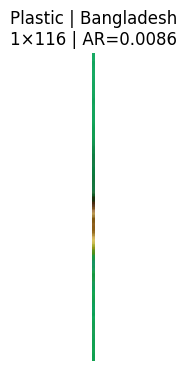

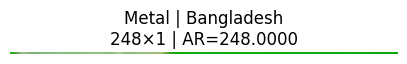

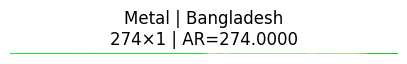

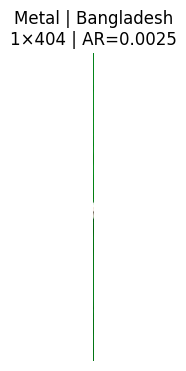

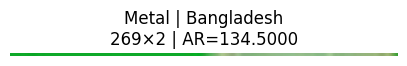

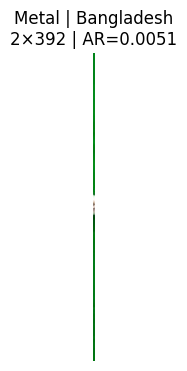

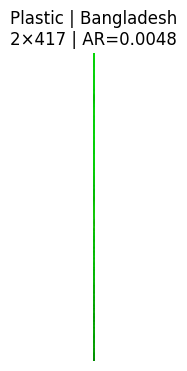

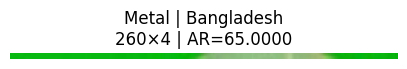

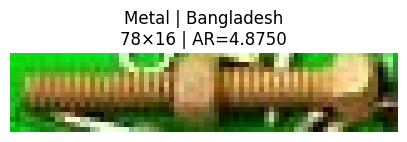

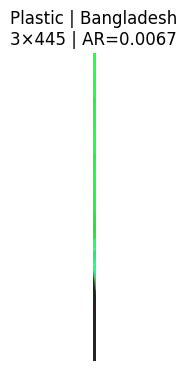

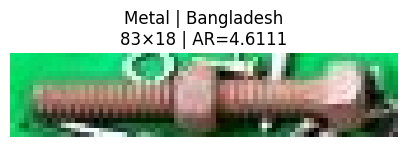

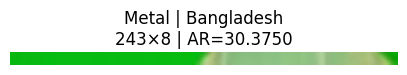

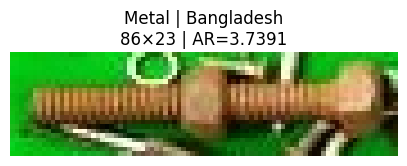

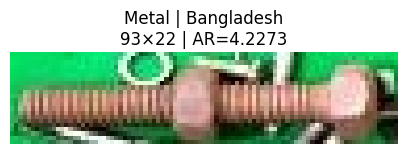

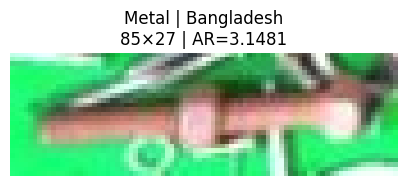

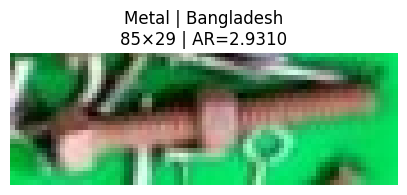

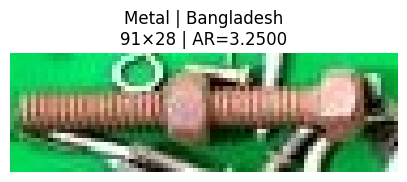

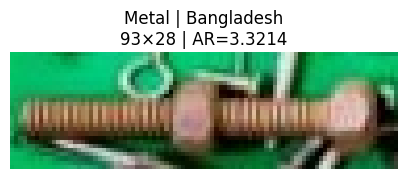

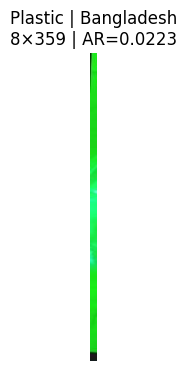

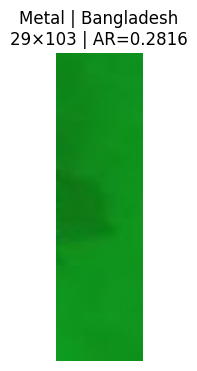

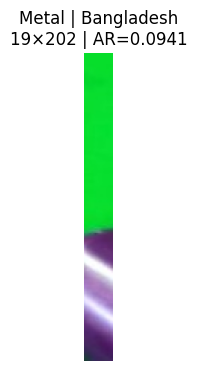

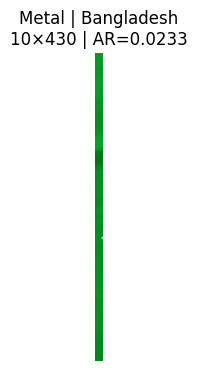

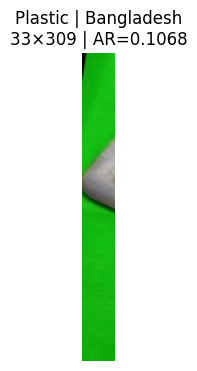

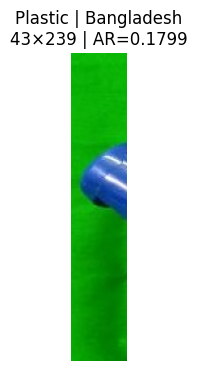

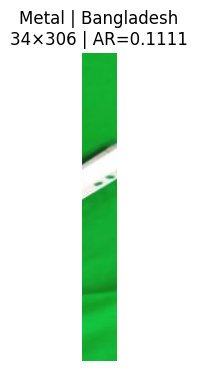

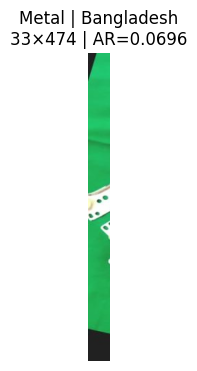

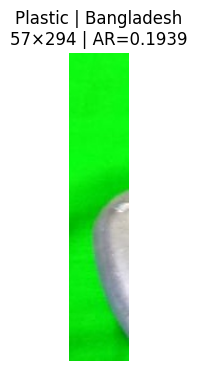

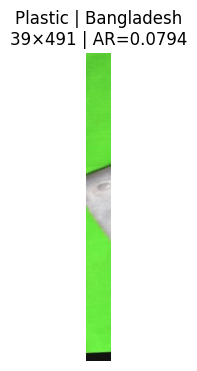

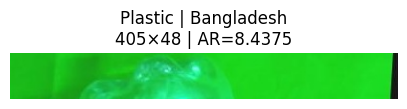

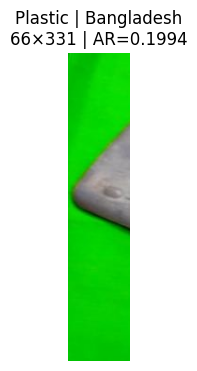

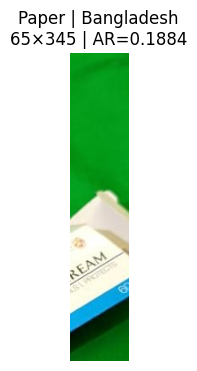

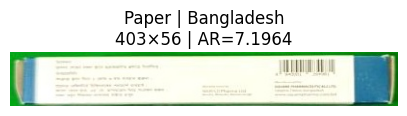

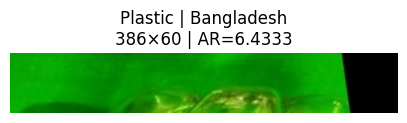

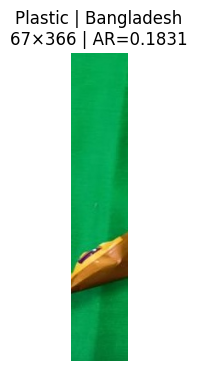

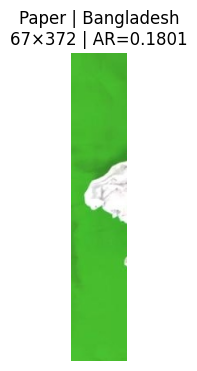

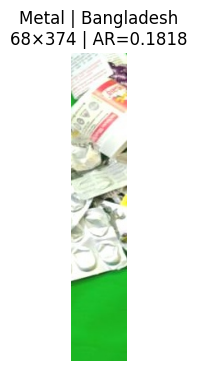

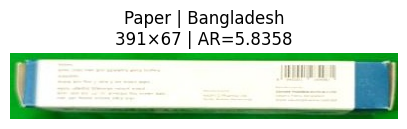

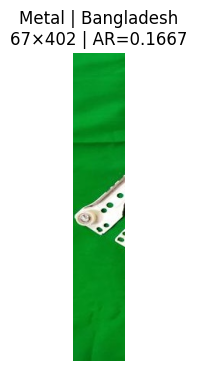

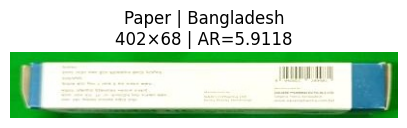

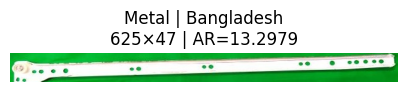

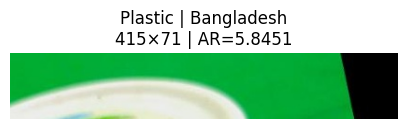

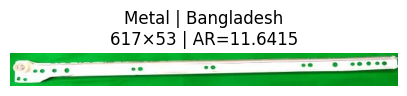

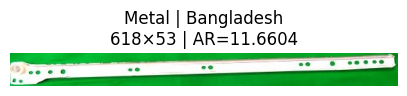

In [61]:
# ============================================================
# VISUAL AUDIT OF FLAGGED IMAGES
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

print("=" * 80)
print("VISUAL AUDIT OF FLAGGED IMAGES")
print("=" * 80)

print(
    "Total flagged:",
    len(flagged_df)
)

# ------------------------------------------------------------
# Sort by severity
# ------------------------------------------------------------

visual_df = (
    flagged_df
    .copy()
    .sort_values(
        ["pixels", "width", "height"],
        ascending=True
    )
)

print(
    "Images to inspect:",
    len(visual_df)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

for idx, row in visual_df.iterrows():

    path = Path(
        row["original_path"]
    )

    try:

        with Image.open(path) as img:

            img = img.convert("RGB")

            plt.figure(
                figsize=(5, 4)
            )

            plt.imshow(img)

            plt.title(
                f'{row["class"]} | '
                f'{row["source"]}\n'
                f'{row["width"]}×{row["height"]} | '
                f'AR={row["aspect_ratio"]:.4f}'
            )

            plt.axis("off")

            plt.show()

    except Exception as e:

        print(
            "ERROR:",
            path,
            e
        )

CREATING FLAGGED IMAGE CONTACT SHEETS
Flagged images: 43
Contact sheets: 2


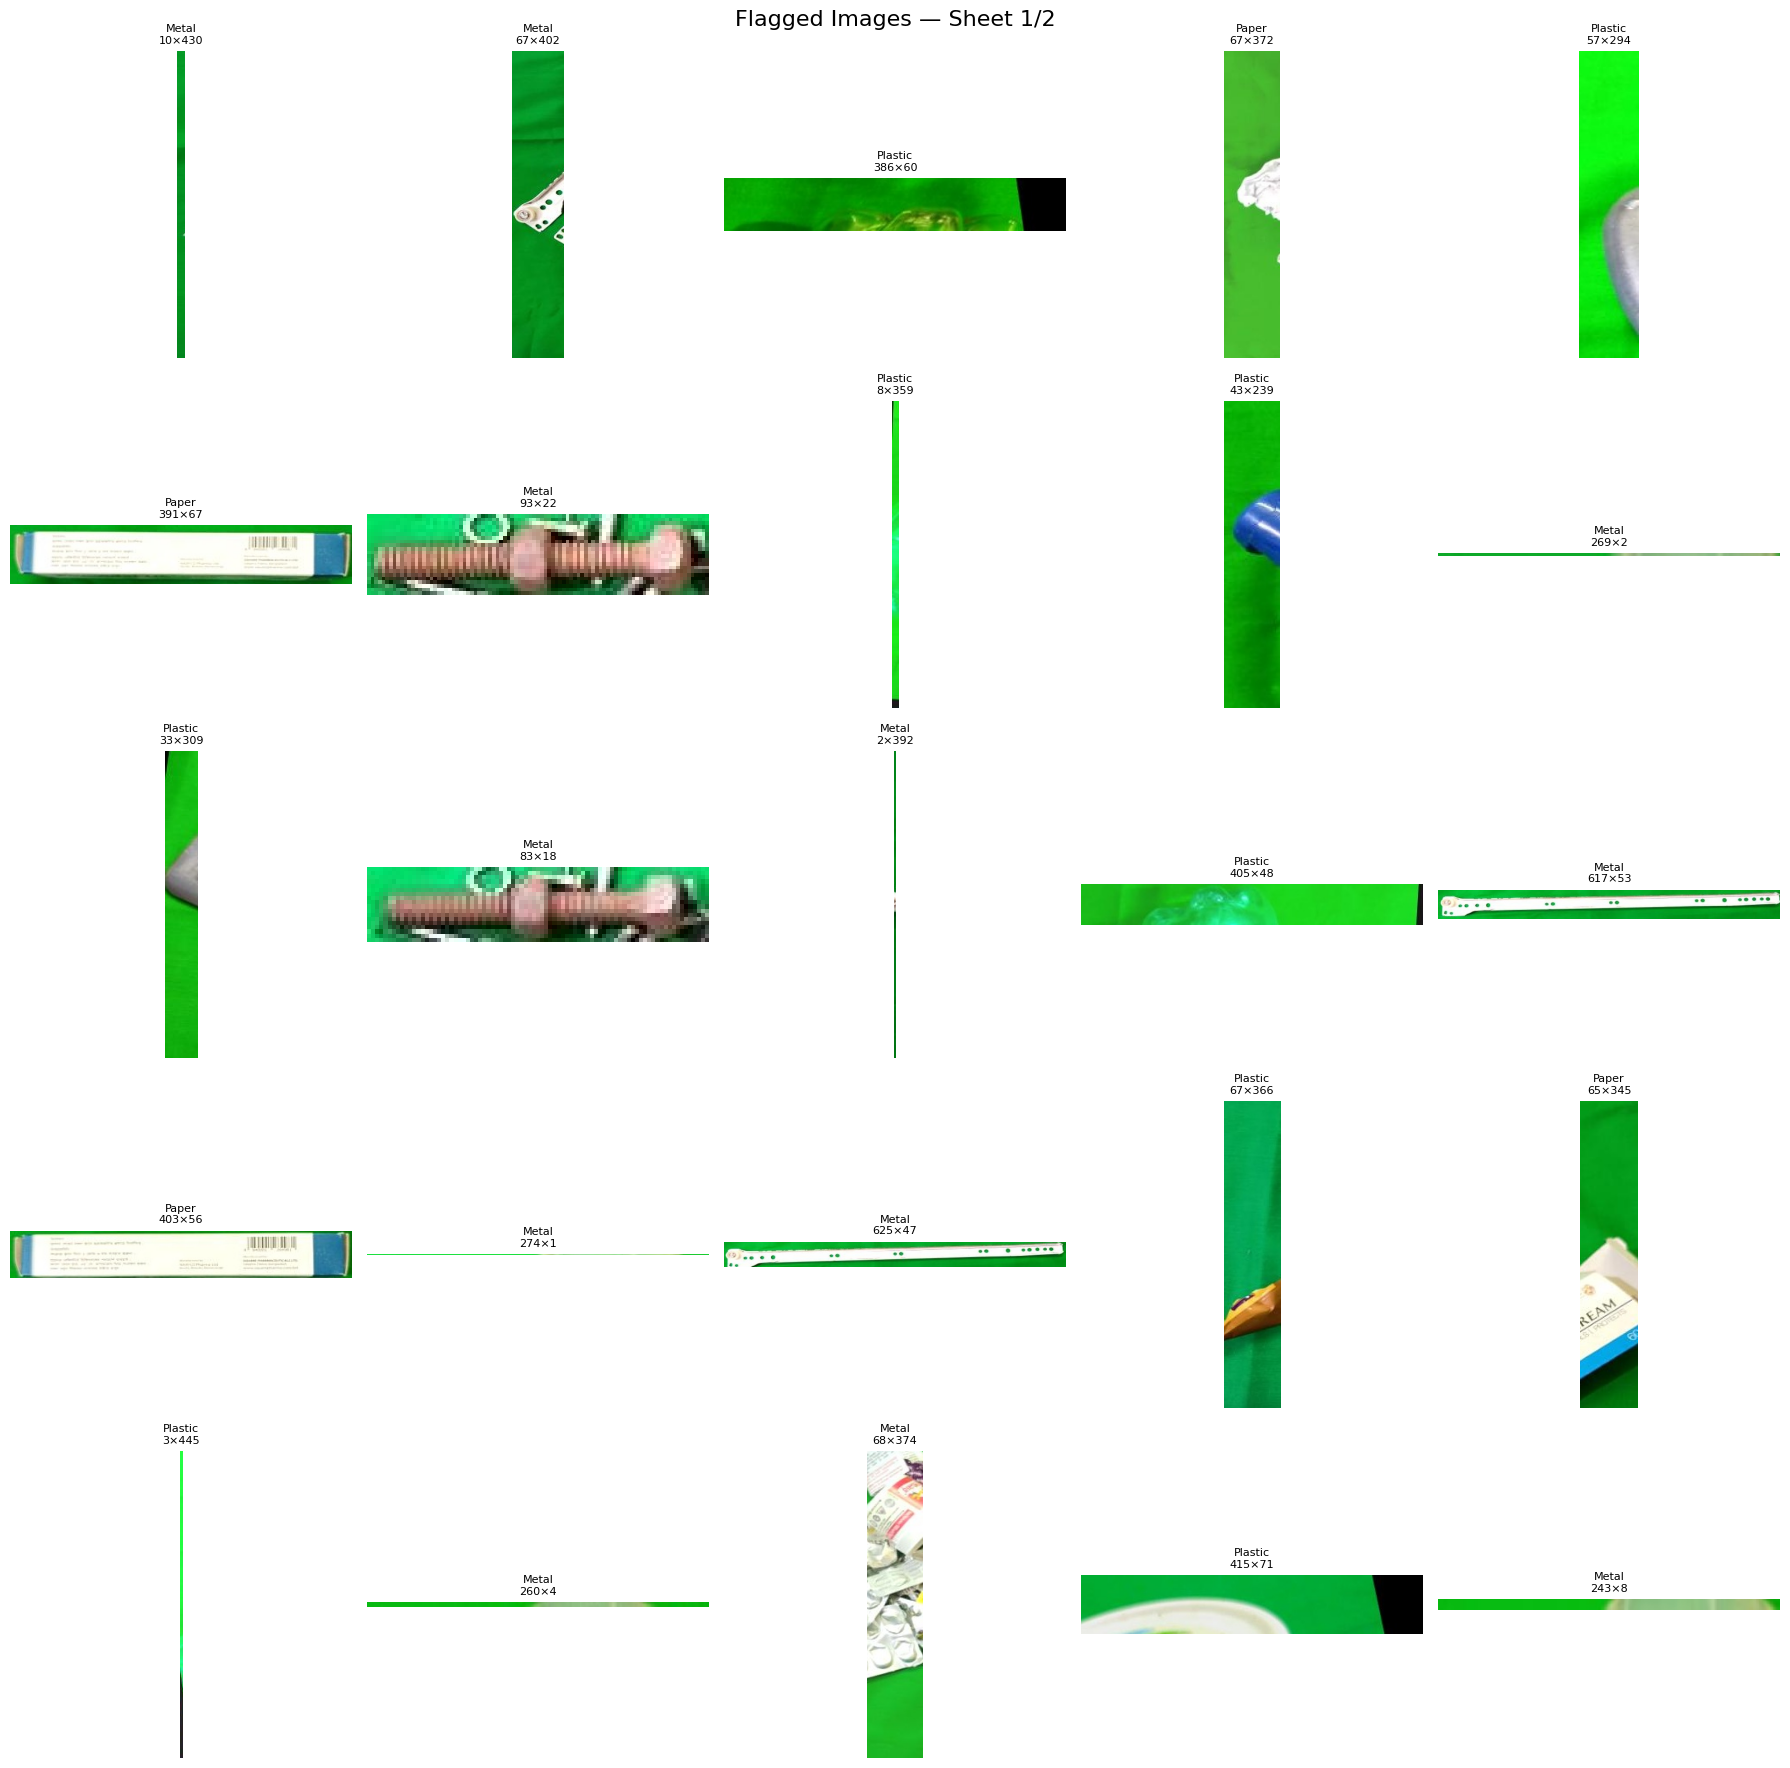

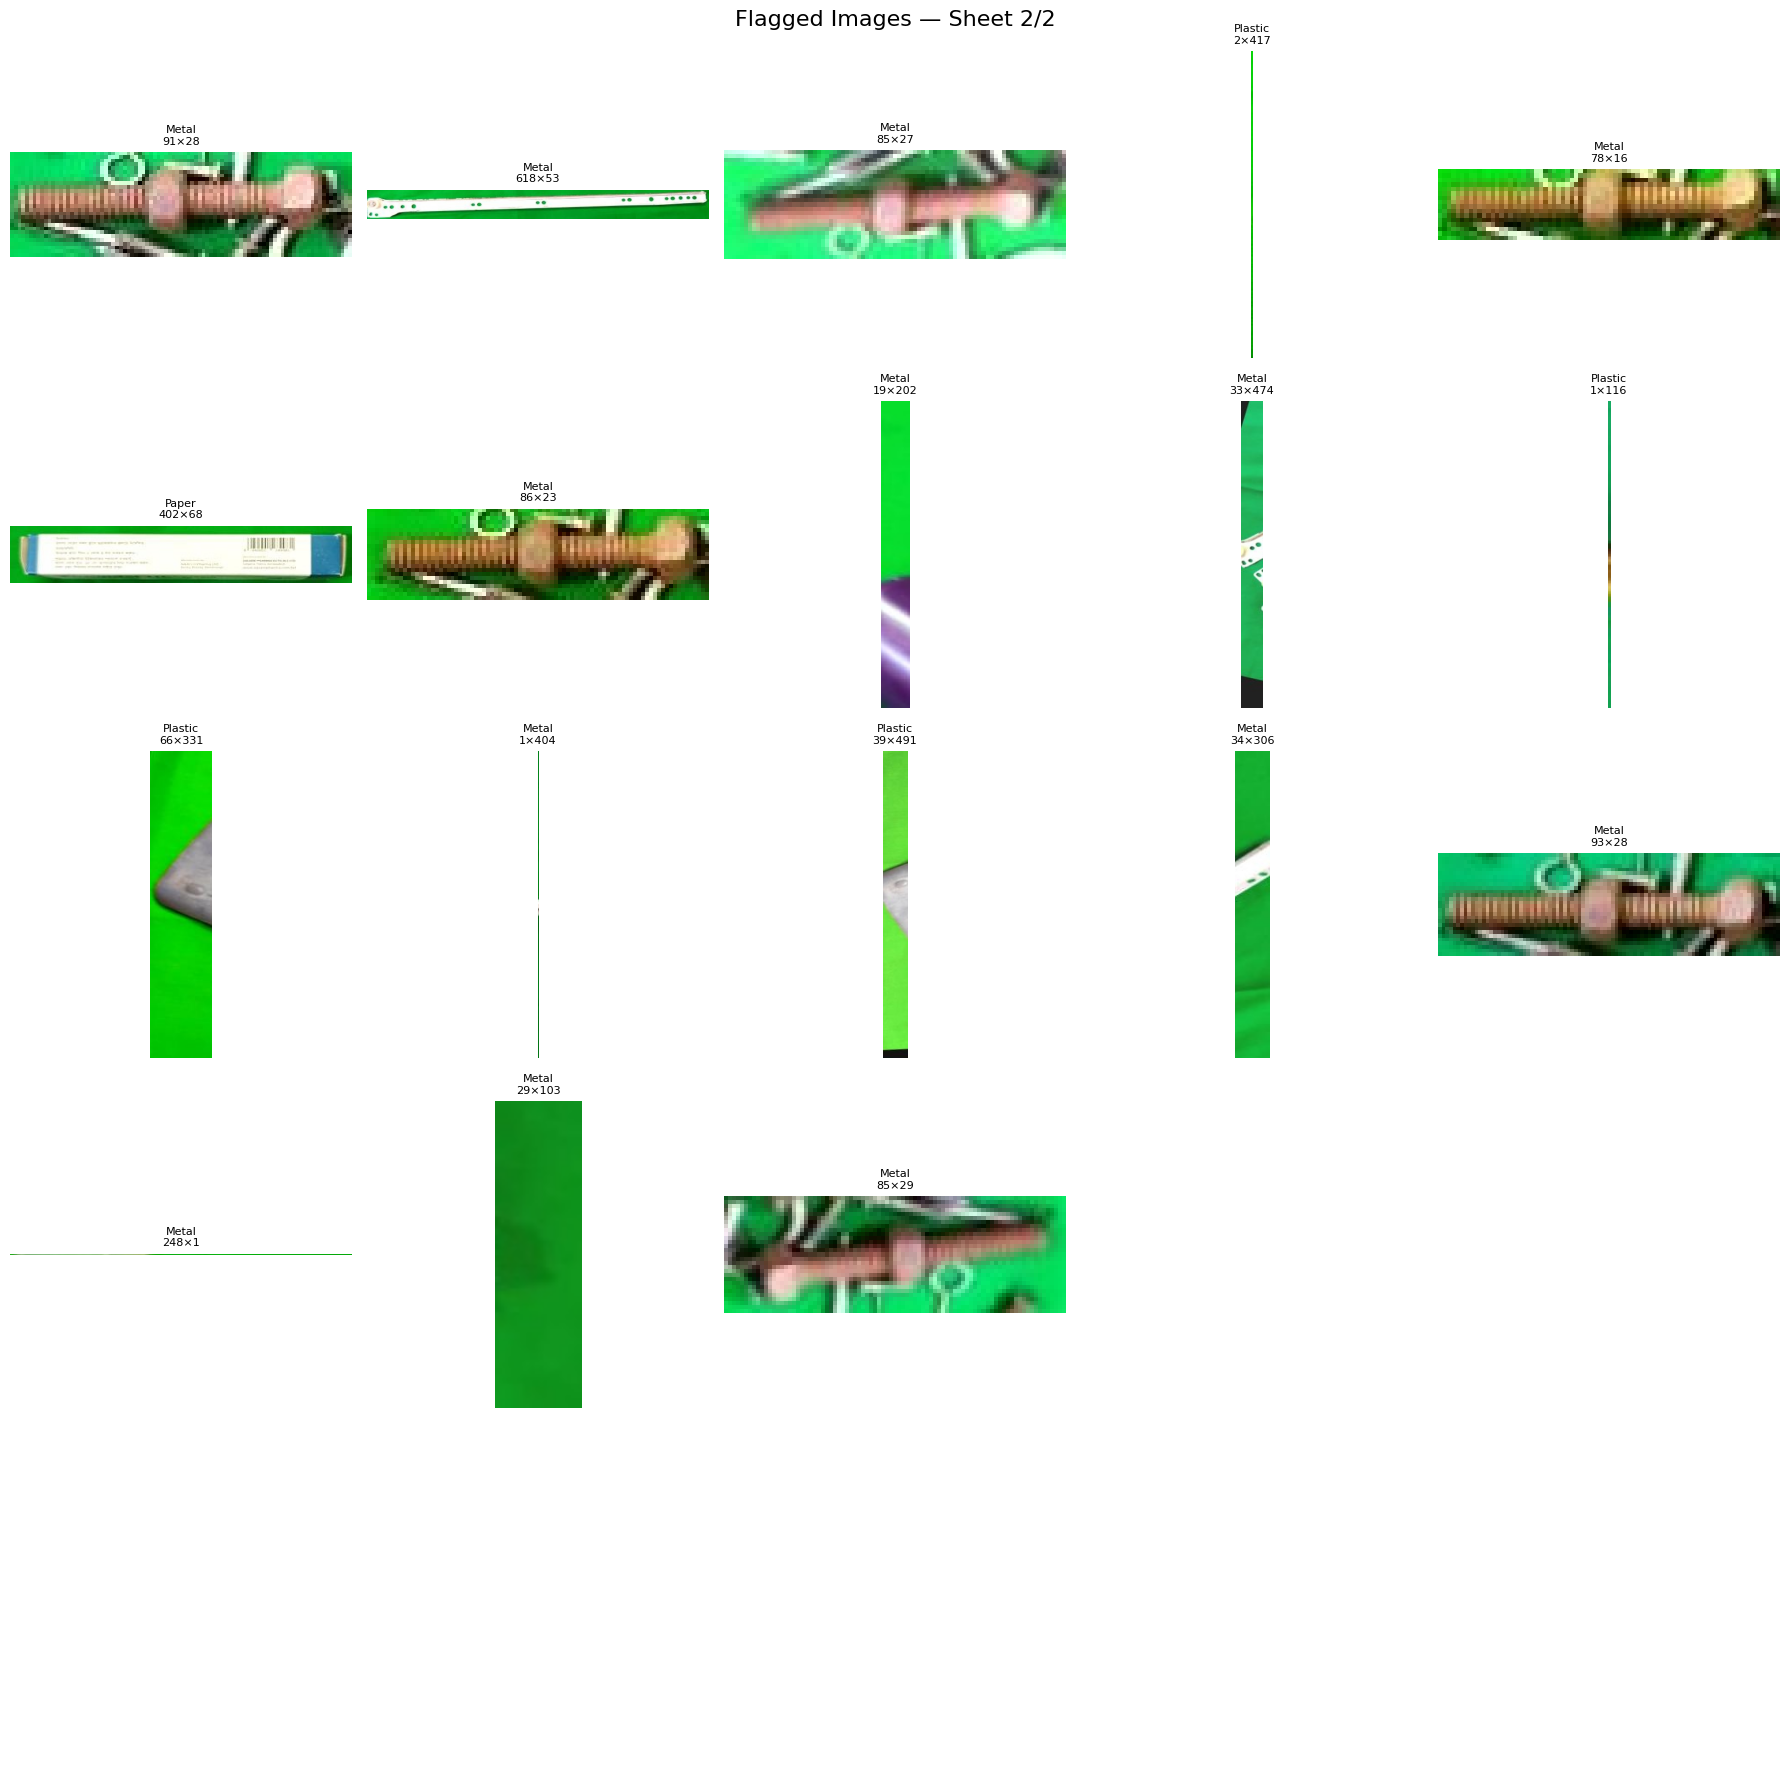


Saved to:
/kaggle/working/Dataset_Reports/flagged_contact_sheets


In [62]:
# ============================================================
# CREATE FLAGGED IMAGE CONTACT SHEET
# ============================================================

import math
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

contact_dir = Path(
    "/kaggle/working/Dataset_Reports/flagged_contact_sheets"
)

contact_dir.mkdir(
    parents=True,
    exist_ok=True
)

images_per_sheet = 25
cols = 5
rows = 5

total = len(flagged_df)

num_sheets = math.ceil(
    total / images_per_sheet
)

print("=" * 80)
print("CREATING FLAGGED IMAGE CONTACT SHEETS")
print("=" * 80)

print(
    "Flagged images:",
    total
)

print(
    "Contact sheets:",
    num_sheets
)

for sheet_idx in range(num_sheets):

    start = (
        sheet_idx *
        images_per_sheet
    )

    end = min(
        start + images_per_sheet,
        total
    )

    subset = flagged_df.iloc[
        start:end
    ]

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(18, 18)
    )

    axes = axes.flatten()

    for ax in axes:

        ax.axis("off")

    for ax, (_, row) in zip(
        axes,
        subset.iterrows()
    ):

        path = Path(
            row["original_path"]
        )

        try:

            img = Image.open(
                path
            ).convert("RGB")

            ax.imshow(img)

            ax.set_title(
                f'{row["class"]}\n'
                f'{row["width"]}×{row["height"]}',
                fontsize=8
            )

            ax.axis("off")

        except Exception as e:

            ax.text(
                0.5,
                0.5,
                "ERROR",
                ha="center",
                va="center"
            )

            ax.axis("off")

    fig.suptitle(
        f"Flagged Images — Sheet {sheet_idx + 1}/{num_sheets}",
        fontsize=16
    )

    plt.tight_layout()

    output = (
        contact_dir /
        f"flagged_sheet_{sheet_idx + 1:02d}.png"
    )

    plt.savefig(
        output,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)

print("\nSaved to:")
print(contact_dir)

In [63]:
# ============================================================
# FLAGGED IMAGE DETAILED AUDIT
# ============================================================

audit_cols = [
    "filename",
    "class",
    "source",
    "width",
    "height",
    "aspect_ratio",
    "pixels",
    "too_small",
    "extreme_aspect",
    "original_path"
]

audit_table = (
    flagged_df[audit_cols]
    .sort_values(
        ["pixels", "aspect_ratio"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

pd.set_option(
    "display.max_colwidth",
    120
)

print("=" * 80)
print("FLAGGED IMAGE DETAILED AUDIT")
print("=" * 80)

print(
    audit_table[
        [
            "filename",
            "class",
            "width",
            "height",
            "aspect_ratio",
            "pixels",
            "too_small",
            "extreme_aspect"
        ]
    ].to_string(index=True)
)

audit_table.to_csv(
    report_dir /
    "flagged_image_detailed_audit.csv",
    index=False
)

print("\nReport saved:")
print(
    report_dir /
    "flagged_image_detailed_audit.csv"
)

FLAGGED IMAGE DETAILED AUDIT
                                                                                      filename    class  width  height  aspect_ratio  pixels  too_small  extreme_aspect
0     BD__EWaste__train__IMG_20250805_205143_jpg.rf.aefcc90f62c9f9cc7ae8e623fcf78c1f__obj0.jpg  Plastic      1     116        0.0086     116       True            True
1     BD__EWaste__train__IMG_20250805_204240_jpg.rf.eb698695bfc2e063c66a3629867f5058__obj0.jpg    Metal    248       1      248.0000     248       True            True
2     BD__EWaste__train__IMG_20250805_204241_jpg.rf.8c3704f64d7cd9886b07a98cd79ca356__obj0.jpg    Metal    274       1      274.0000     274       True            True
3      BD__EWaste__test__IMG_20250822_141136_jpg.rf.0be4d2fca3b4f606057e95da0a6c36a2__obj0.jpg    Metal      1     404        0.0025     404       True            True
4     BD__EWaste__train__IMG_20250805_204242_jpg.rf.954bdd581387fcb523d672277e062514__obj0.jpg    Metal    269       2      134.500

In [64]:
# ============================================================
# AUTOMATIC SEVERITY CLASSIFICATION
# ============================================================

def classify_quality(row):

    w = row["width"]
    h = row["height"]
    ar = row["aspect_ratio"]

    # ----------------------------------------
    # Definitely unusable
    # ----------------------------------------

    if w <= 4 or h <= 4:
        return "REMOVE_DEFINITE"

    # ----------------------------------------
    # Very low resolution
    # ----------------------------------------

    if w < 32 or h < 32:
        return "REMOVE_DEFINITE"

    # ----------------------------------------
    # Extreme crop
    # ----------------------------------------

    if ar < 0.05 or ar > 20:
        return "REMOVE_DEFINITE"

    # ----------------------------------------
    # Strongly suspicious
    # ----------------------------------------

    if ar < 0.20 or ar > 5:
        return "REVIEW"

    # ----------------------------------------
    # Otherwise
    # ----------------------------------------

    return "KEEP"

audit_table["decision"] = (
    audit_table.apply(
        classify_quality,
        axis=1
    )
)

print("=" * 80)
print("AUTOMATIC QUALITY DECISION")
print("=" * 80)

print(
    audit_table["decision"]
    .value_counts()
)

print("\nBy class:")

print(
    pd.crosstab(
        audit_table["class"],
        audit_table["decision"]
    )
)

AUTOMATIC QUALITY DECISION
decision
REMOVE_DEFINITE    22
REVIEW             21
Name: count, dtype: int64

By class:
decision  REMOVE_DEFINITE  REVIEW
class                            
Metal                  18       7
Paper                   0       5
Plastic                 4       9


In [65]:
# ============================================================
# REVIEW-ONLY IMAGES
# ============================================================

review_df = (
    audit_table[
        audit_table["decision"] == "REVIEW"
    ]
    .reset_index(drop=True)
)

print("=" * 80)
print("MANUAL REVIEW REQUIRED")
print("=" * 80)

print(
    "Review images:",
    len(review_df)
)

if len(review_df) > 0:

    print(
        review_df[
            [
                "filename",
                "class",
                "width",
                "height",
                "aspect_ratio",
                "pixels",
                "original_path"
            ]
        ].to_string(index=False)
    )
else:

    print(
        "No additional manual review required."
    )

MANUAL REVIEW REQUIRED
Review images: 21
                                                                                  filename   class  width  height  aspect_ratio  pixels                                                                                                                          original_path
  BD__EWaste__train__IMG_20250803_221008_jpg.rf.da0a58ab4adc358f295b8346a8f7032e__obj0.jpg Plastic     33     309        0.1068   10197   /kaggle/working/Bangladesh_5Class_Clean/Plastic/EWaste__train__IMG_20250803_221008_jpg.rf.da0a58ab4adc358f295b8346a8f7032e__obj0.jpg
  BD__EWaste__valid__IMG_20250822_142044_jpg.rf.06aed6639286974ef38a3fe5c06eacd7__obj0.jpg Plastic     43     239        0.1799   10277   /kaggle/working/Bangladesh_5Class_Clean/Plastic/EWaste__valid__IMG_20250822_142044_jpg.rf.06aed6639286974ef38a3fe5c06eacd7__obj0.jpg
  BD__EWaste__train__IMG_20250822_141138_jpg.rf.7aa38ade6237cbabbaa0230d6ff4639c__obj0.jpg   Metal     34     306        0.1111   10404     /kaggl

In [66]:
# ============================================================
# STEP 1 — FINAL REVIEW IMAGE AUDIT SHEET
# ============================================================

from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import math

print("=" * 80)
print("FINAL REVIEW IMAGE AUDIT")
print("=" * 80)

review_df = (
    audit_table[
        audit_table["decision"] == "REVIEW"
    ]
    .copy()
    .reset_index(drop=True)
)

print("Review images:", len(review_df))

# Save review metadata
review_report = (
    report_dir /
    "final_review_images.csv"
)

review_df[
    [
        "filename",
        "class",
        "source",
        "width",
        "height",
        "aspect_ratio",
        "pixels",
        "original_path"
    ]
].to_csv(
    review_report,
    index=False
)

print("Saved:", review_report)

FINAL REVIEW IMAGE AUDIT
Review images: 21
Saved: /kaggle/working/Dataset_Reports/final_review_images.csv


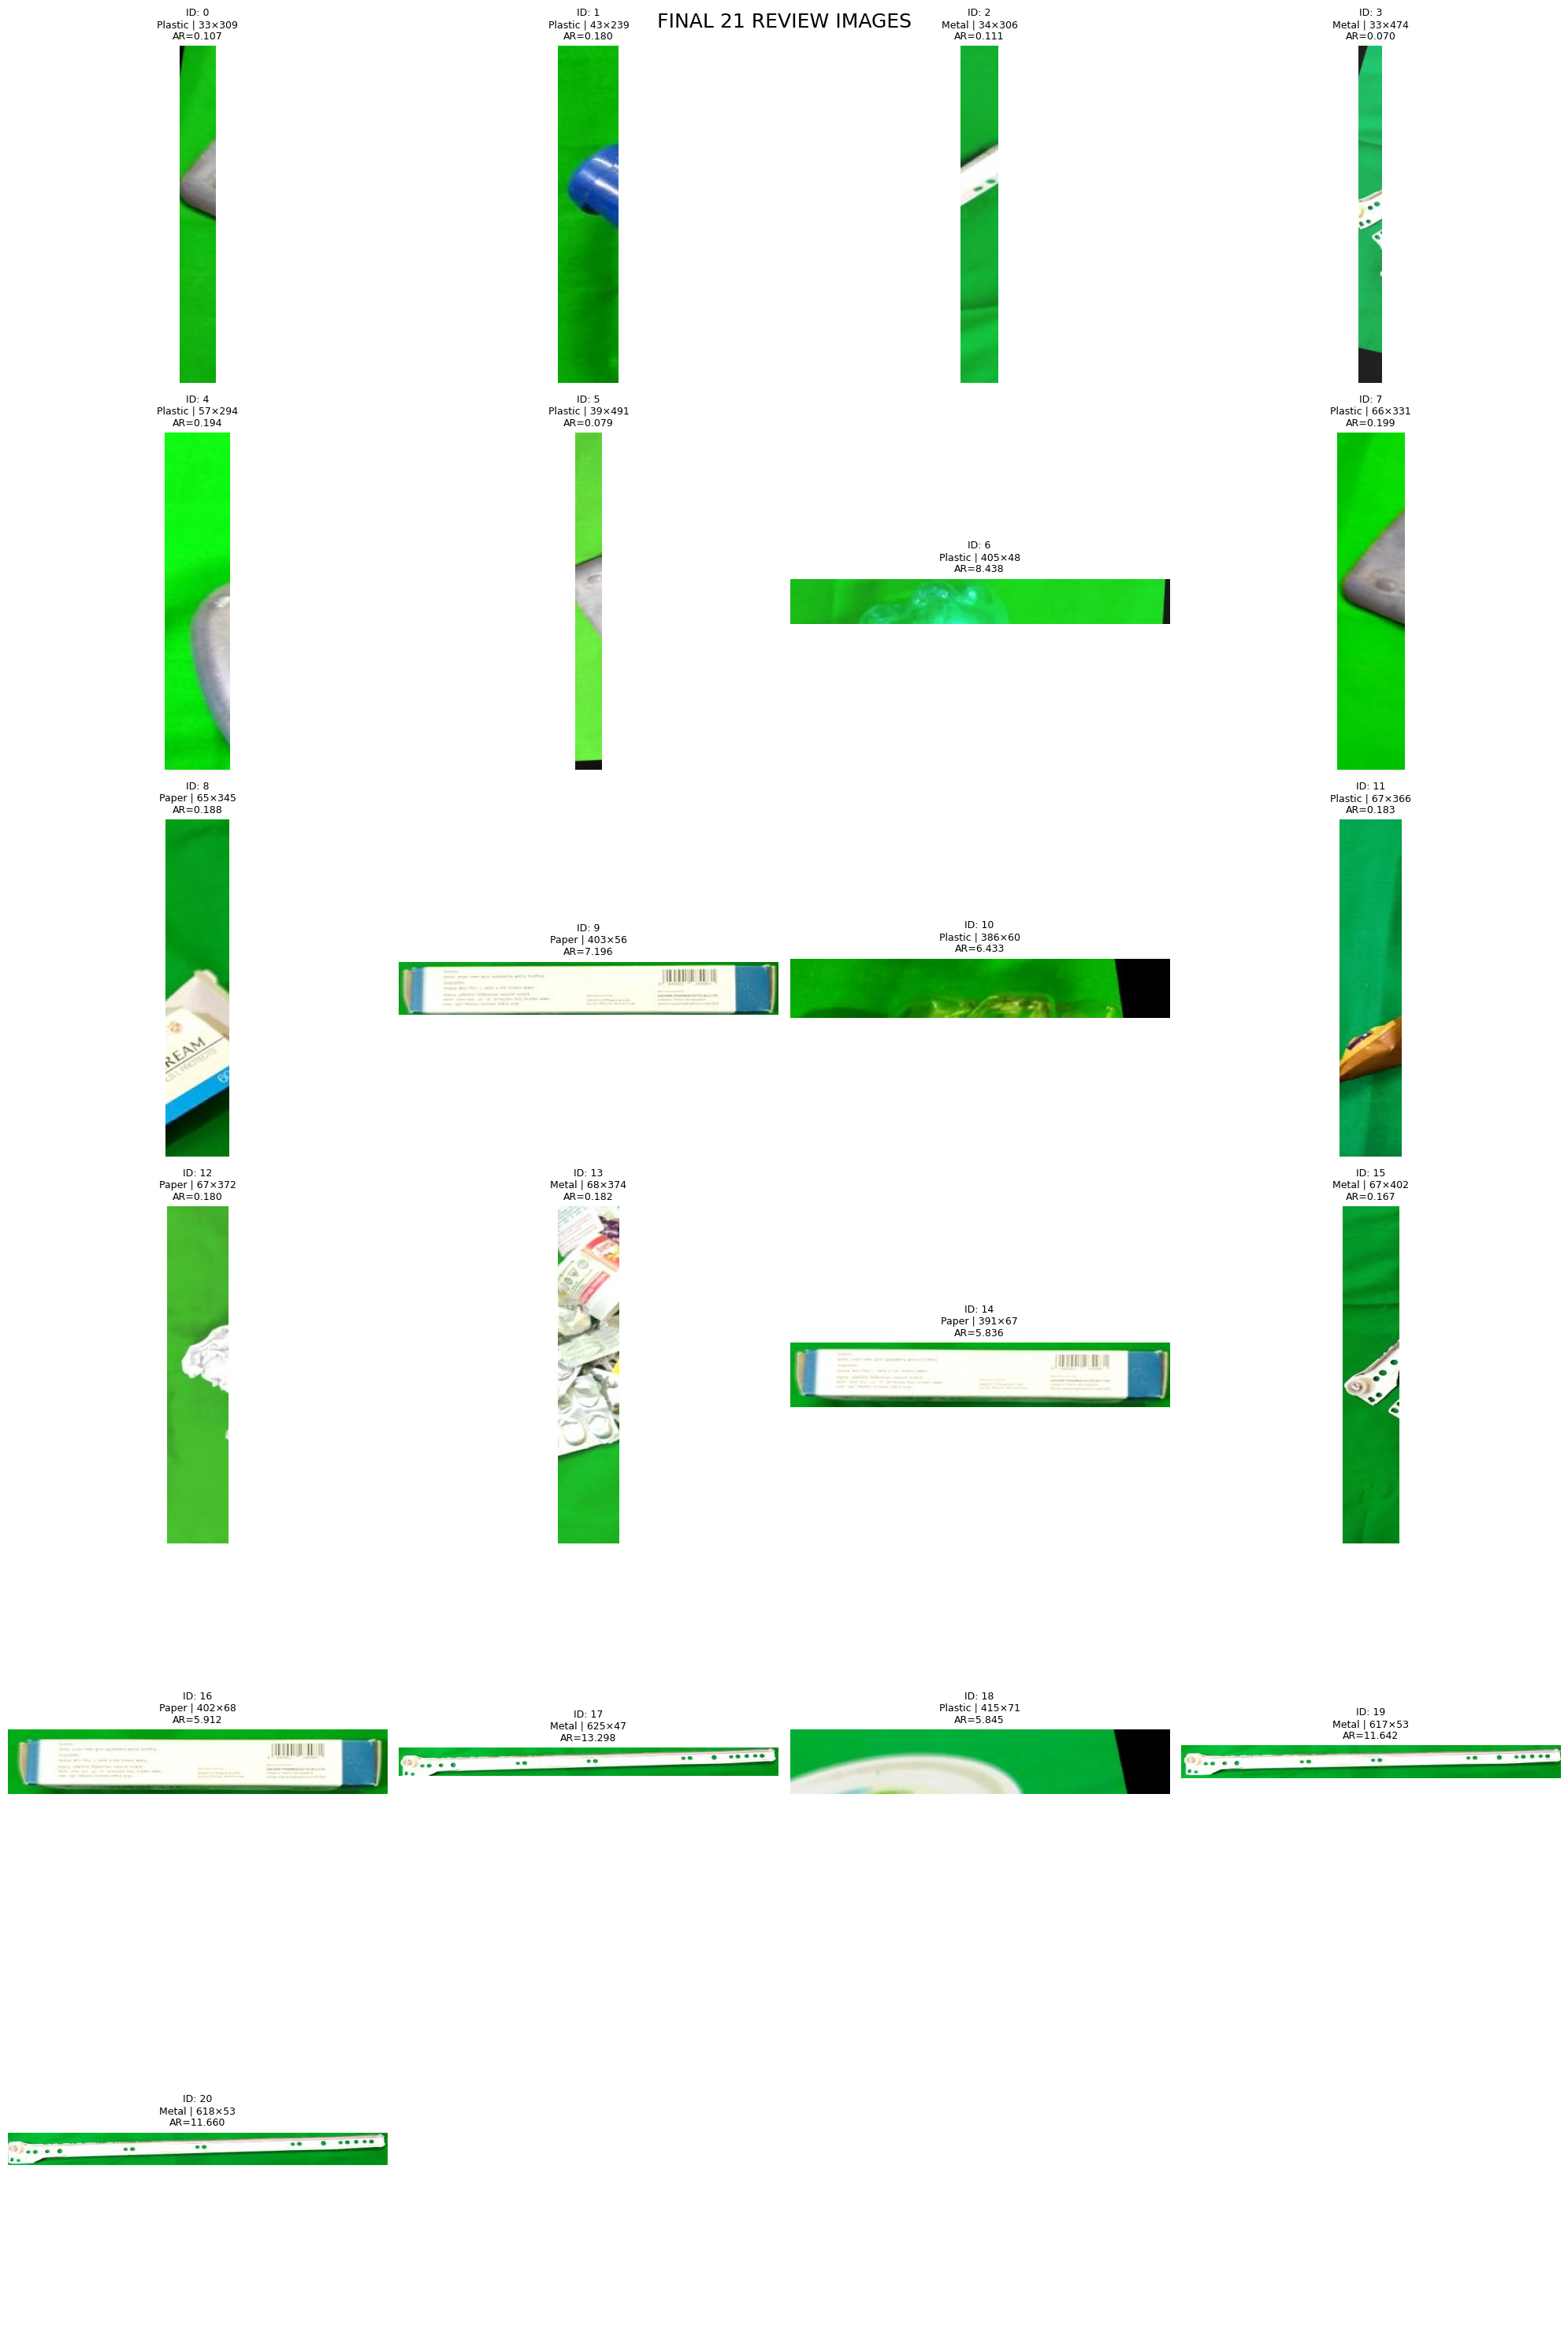


Contact sheet saved:
/kaggle/working/Dataset_Reports/final_review_contact_sheets/review_images_all.png


In [67]:
# ============================================================
# STEP 2 — REVIEW CONTACT SHEET
# ============================================================

contact_dir = (
    report_dir /
    "final_review_contact_sheets"
)

contact_dir.mkdir(
    parents=True,
    exist_ok=True
)

cols = 4
rows = math.ceil(len(review_df) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(20, rows * 5)
)

axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for idx, row in review_df.iterrows():

    path = Path(
        row["original_path"]
    )

    try:

        img = Image.open(path).convert("RGB")

        axes[idx].imshow(img)

        axes[idx].set_title(
            f'ID: {idx}\n'
            f'{row["class"]} | '
            f'{row["width"]}×{row["height"]}\n'
            f'AR={row["aspect_ratio"]:.3f}',
            fontsize=9
        )

        axes[idx].axis("off")

    except Exception as e:

        axes[idx].text(
            0.5,
            0.5,
            "ERROR",
            ha="center",
            va="center"
        )

        print(
            "ERROR:",
            path,
            e
        )

fig.suptitle(
    "FINAL 21 REVIEW IMAGES",
    fontsize=18
)

plt.tight_layout()

review_sheet = (
    contact_dir /
    "review_images_all.png"
)

plt.savefig(
    review_sheet,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

print(
    "\nContact sheet saved:"
)

print(review_sheet)

In [68]:
# ============================================================
# STEP 3 — MANUAL REVIEW DECISION TABLE
# ============================================================

manual_review = review_df[
    [
        "filename",
        "class",
        "source",
        "width",
        "height",
        "aspect_ratio",
        "pixels",
        "original_path"
    ]
].copy()

manual_review["decision"] = "KEEP"

manual_review["reason"] = ""

print("=" * 80)
print("MANUAL REVIEW TABLE")
print("=" * 80)

print(
    manual_review[
        [
            "filename",
            "class",
            "width",
            "height",
            "aspect_ratio",
            "decision"
        ]
    ].to_string(index=True)
)

MANUAL REVIEW TABLE
                                                                                      filename    class  width  height  aspect_ratio decision
0     BD__EWaste__train__IMG_20250803_221008_jpg.rf.da0a58ab4adc358f295b8346a8f7032e__obj0.jpg  Plastic     33     309        0.1068     KEEP
1     BD__EWaste__valid__IMG_20250822_142044_jpg.rf.06aed6639286974ef38a3fe5c06eacd7__obj0.jpg  Plastic     43     239        0.1799     KEEP
2     BD__EWaste__train__IMG_20250822_141138_jpg.rf.7aa38ade6237cbabbaa0230d6ff4639c__obj0.jpg    Metal     34     306        0.1111     KEEP
3     BD__EWaste__train__IMG_20250822_141130_jpg.rf.79966f3c2e1a2134b6e3f7bcd437063a__obj0.jpg    Metal     33     474        0.0696     KEEP
4     BD__EWaste__train__IMG_20250803_221006_jpg.rf.6c4a21e56bb01160b3ccd15086edee95__obj0.jpg  Plastic     57     294        0.1939     KEEP
5     BD__EWaste__train__IMG_20250803_221008_jpg.rf.24aa80e898b745bd985589f57eee71f2__obj0.jpg  Plastic     39     491        0.

In [69]:
# ============================================================
# STEP 5 — CONSERVATIVE REVIEW POLICY
# ============================================================

manual_review["decision"] = "KEEP"

manual_review["reason"] = (
    "Visually review; retain unless object is "
    "clearly unusable after visual inspection."
)

print(
    manual_review["decision"].value_counts()
)

decision
KEEP    21
Name: count, dtype: int64


In [70]:
# ============================================================
# STEP 6 — BUILD FINAL REMOVAL LIST
# ============================================================

definite_remove = audit_table[
    audit_table["decision"] == "REMOVE_DEFINITE"
].copy()

manual_remove = manual_review[
    manual_review["decision"] == "REMOVE"
].copy()

final_remove = pd.concat(
    [
        definite_remove,
        manual_remove
    ],
    ignore_index=True
)

print("=" * 80)
print("FINAL REMOVAL SUMMARY")
print("=" * 80)

print(
    "Definite removal:",
    len(definite_remove)
)

print(
    "Manual removal:",
    len(manual_remove)
)

print(
    "Total removal:",
    len(final_remove)
)

print(
    "Expected final dataset:",
    len(df) - len(final_remove)
)

FINAL REMOVAL SUMMARY
Definite removal: 22
Manual removal: 0
Total removal: 22
Expected final dataset: 10668


In [71]:
# ============================================================
# STEP 7 — SAVE FINAL REMOVAL REPORT
# ============================================================

final_remove_report = (
    report_dir /
    "final_removed_images.csv"
)

final_remove.to_csv(
    final_remove_report,
    index=False
)

print(
    "Final removal report:"
)

print(final_remove_report)

Final removal report:
/kaggle/working/Dataset_Reports/final_removed_images.csv


In [72]:
# ============================================================
# STEP 8 — FINAL CLEAN METADATA
# ============================================================

remove_paths = set(
    final_remove["original_path"]
)

final_df = df[
    ~df["original_path"].isin(
        remove_paths
    )
].copy()

final_df = (
    final_df
    .reset_index(drop=True)
)

print("=" * 80)
print("FINAL CLEAN DATASET")
print("=" * 80)

print(
    "Original:",
    len(df)
)

print(
    "Removed:",
    len(final_remove)
)

print(
    "Final:",
    len(final_df)
)

print("\nClass distribution:")

print(
    final_df["class"]
    .value_counts()
    .sort_index()
)

print("\nSource distribution:")

print(
    final_df["source"]
    .value_counts()
)

FINAL CLEAN DATASET
Original: 10690
Removed: 22
Final: 10668

Class distribution:
class
Cardboard    1720
Glass        2112
Metal        2315
Paper        2662
Plastic      1859
Name: count, dtype: int64

Source distribution:
source
International    8592
Bangladesh       2076
Name: count, dtype: int64


In [73]:
# ============================================================
# STEP 9 — CLEAN EXISTING SPLITS
# ============================================================

clean_train_df = train_df[
    ~train_df["original_path"].isin(
        remove_paths
    )
].copy()

clean_val_df = val_df[
    ~val_df["original_path"].isin(
        remove_paths
    )
].copy()

clean_test_df = test_df[
    ~test_df["original_path"].isin(
        remove_paths
    )
].copy()

clean_bd_test_df = bd_test[
    ~bd_test["original_path"].isin(
        remove_paths
    )
].copy()

clean_intl_test_df = international_test_df[
    ~international_test_df["original_path"].isin(
        remove_paths
    )
].copy()

print("=" * 80)
print("CLEANED SPLITS")
print("=" * 80)

print(
    "Train:",
    len(clean_train_df)
)

print(
    "Validation:",
    len(clean_val_df)
)

print(
    "Test:",
    len(clean_test_df)
)

print(
    "Bangladesh Test:",
    len(clean_bd_test_df)
)

print(
    "International Test:",
    len(clean_intl_test_df)
)

CLEANED SPLITS
Train: 7245
Validation: 1552
Test: 1871
Bangladesh Test: 319
International Test: 1289


In [74]:
# ============================================================
# STEP 10 — FINAL LEAKAGE CHECK
# ============================================================

train_paths = set(
    clean_train_df["original_path"]
)

val_paths = set(
    clean_val_df["original_path"]
)

test_paths = set(
    clean_test_df["original_path"]
)

print("=" * 80)
print("FINAL LEAKAGE CHECK")
print("=" * 80)

print(
    "Train ∩ Validation:",
    len(train_paths & val_paths)
)

print(
    "Train ∩ Test:",
    len(train_paths & test_paths)
)

print(
    "Validation ∩ Test:",
    len(val_paths & test_paths)
)

FINAL LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [75]:
# ============================================================
# STEP 11 — FINAL DATASET DISTRIBUTION
# ============================================================

for name, data in [
    ("TRAIN", clean_train_df),
    ("VALIDATION", clean_val_df),
    ("TEST", clean_test_df),
    ("BANGLADESH TEST", clean_bd_test_df),
    ("INTERNATIONAL TEST", clean_intl_test_df)
]:

    print("\n" + "=" * 70)
    print(name)

    print("\nTotal:", len(data))

    print("\nClass:")

    print(
        data["class"]
        .value_counts()
        .sort_index()
    )

    print("\nSource:")

    print(
        data["source"]
        .value_counts()
    )


TRAIN

Total: 7245

Class:
class
Cardboard    1193
Glass        1433
Metal        1594
Paper        1793
Plastic      1232
Name: count, dtype: int64

Source:
source
International    6014
Bangladesh       1231
Name: count, dtype: int64

VALIDATION

Total: 1552

Class:
class
Cardboard    255
Glass        307
Metal        341
Paper        385
Plastic      264
Name: count, dtype: int64

Source:
source
International    1289
Bangladesh        263
Name: count, dtype: int64

TEST

Total: 1871

Class:
class
Cardboard    272
Glass        372
Metal        380
Paper        484
Plastic      363
Name: count, dtype: int64

Source:
source
International    1289
Bangladesh        582
Name: count, dtype: int64

BANGLADESH TEST

Total: 319

Class:
class
Cardboard     15
Glass         65
Metal         40
Paper        100
Plastic       99
Name: count, dtype: int64

Source:
source
Bangladesh    319
Name: count, dtype: int64

INTERNATIONAL TEST

Total: 1289

Class:
class
Cardboard    248
Glass        252
Met

# ## #  SAVE FINAL RESEARCH METADATA

In [76]:
# ============================================================
# STEP 12 — SAVE FINAL RESEARCH METADATA
# ============================================================

final_metadata_dir = (
    Path("/kaggle/working")
    / "Final_Waste_Dataset"
    / "research_metadata"
)

final_metadata_dir.mkdir(
    parents=True,
    exist_ok=True
)

final_df.to_csv(
    final_metadata_dir /
    "final_metadata.csv",
    index=False
)

clean_train_df.to_csv(
    final_metadata_dir /
    "train_final.csv",
    index=False
)

clean_val_df.to_csv(
    final_metadata_dir /
    "validation_final.csv",
    index=False
)

clean_test_df.to_csv(
    final_metadata_dir /
    "test_final.csv",
    index=False
)

clean_bd_test_df.to_csv(
    final_metadata_dir /
    "test_bangladesh_final.csv",
    index=False
)

clean_intl_test_df.to_csv(
    final_metadata_dir /
    "test_international_final.csv",
    index=False
)

manual_review.to_csv(
    final_metadata_dir /
    "manual_review_decisions.csv",
    index=False
)

print("=" * 80)
print("FINAL RESEARCH METADATA SAVED")
print("=" * 80)

print(final_metadata_dir)

FINAL RESEARCH METADATA SAVED
/kaggle/working/Final_Waste_Dataset/research_metadata


In [77]:
# ============================================================
# STEP 13 — CHECK KAGGLE DISK BEFORE FINAL PHYSICAL BUILD
# ============================================================

import shutil
from pathlib import Path

print("=" * 80)
print("KAGGLE STORAGE CHECK")
print("=" * 80)

total, used, free = shutil.disk_usage("/kaggle/working")

print(f"Total : {total / (1024**3):.2f} GB")
print(f"Used  : {used / (1024**3):.2f} GB")
print(f"Free  : {free / (1024**3):.2f} GB")

print("\nExisting Final_Waste_Dataset:")

existing_root = Path(
    "/kaggle/working/Final_Waste_Dataset"
)

if existing_root.exists():

    size_bytes = sum(
        p.stat().st_size
        for p in existing_root.rglob("*")
        if p.is_file()
    )

    print(
        f"Existing size: "
        f"{size_bytes / (1024**3):.2f} GB"
    )

else:

    print("Does not exist.")

KAGGLE STORAGE CHECK
Total : 19.52 GB
Used  : 17.89 GB
Free  : 1.61 GB

Existing Final_Waste_Dataset:
Existing size: 3.53 GB


In [78]:
# ============================================================
# STEP 13 — SAFE DISK CLEANUP
# ============================================================

import shutil
from pathlib import Path
import os

print("=" * 80)
print("SAFE DISK CLEANUP")
print("=" * 80)

WORK_ROOT = Path("/kaggle/working")

# ------------------------------------------------------------
# IMPORTANT:
# Keep research metadata.
# Remove ONLY incomplete physical dataset and backup attempts.
# ------------------------------------------------------------

paths_to_remove = [
    WORK_ROOT / "Final_Waste_Dataset_Backup",
    WORK_ROOT / "Final_Research_Metadata_Backup",
]

# Incomplete physical folders
final_root = WORK_ROOT / "Final_Waste_Dataset"

# We want to preserve research_metadata.
# Remove only physical image directories.
physical_dirs = [
    final_root / "train",
    final_root / "validation",
    final_root / "test",
    final_root / "test_bangladesh",
    final_root / "test_international",
]

for path in paths_to_remove:

    if path.exists():

        print("Removing:", path)

        shutil.rmtree(
            path,
            ignore_errors=False
        )

        print("✓ Removed")

    else:

        print("Not found:", path)


# ------------------------------------------------------------
# Remove incomplete physical split folders
# ------------------------------------------------------------

for path in physical_dirs:

    if path.exists():

        print("\nRemoving incomplete physical split:")
        print(path)

        shutil.rmtree(
            path,
            ignore_errors=False
        )

        print("✓ Removed")

    else:

        print("\nNot found:", path)


# ------------------------------------------------------------
# Check metadata still exists
# ------------------------------------------------------------

metadata_root = (
    final_root /
    "research_metadata"
)

print("\n" + "=" * 80)
print("METADATA CHECK")
print("=" * 80)

if metadata_root.exists():

    print(
        "✓ Research metadata preserved:"
    )

    for file in sorted(
        metadata_root.glob("*.csv")
    ):

        print(
            f"{file.name:<35} "
            f"{file.stat().st_size / 1024:.1f} KB"
        )

else:

    print(
        "⚠ Research metadata directory not found!"
    )


# ------------------------------------------------------------
# Storage after cleanup
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STORAGE AFTER CLEANUP")
print("=" * 80)

total, used, free = shutil.disk_usage(
    WORK_ROOT
)

print(
    f"Total : {total / (1024**3):.2f} GB"
)

print(
    f"Used  : {used / (1024**3):.2f} GB"
)

print(
    f"Free  : {free / (1024**3):.2f} GB"
)

SAFE DISK CLEANUP
Not found: /kaggle/working/Final_Waste_Dataset_Backup
Not found: /kaggle/working/Final_Research_Metadata_Backup

Not found: /kaggle/working/Final_Waste_Dataset/train

Not found: /kaggle/working/Final_Waste_Dataset/validation

Not found: /kaggle/working/Final_Waste_Dataset/test

Not found: /kaggle/working/Final_Waste_Dataset/test_bangladesh

Not found: /kaggle/working/Final_Waste_Dataset/test_international

METADATA CHECK
✓ Research metadata preserved:
final_metadata.csv                  2020.0 KB
manual_review_decisions.csv         7.2 KB
test_bangladesh_final.csv           64.5 KB
test_final.csv                      356.4 KB
test_international_final.csv        238.9 KB
train_final.csv                     1370.4 KB
validation_final.csv                293.3 KB

STORAGE AFTER CLEANUP
Total : 19.52 GB
Used  : 17.89 GB
Free  : 1.61 GB


In [79]:
# ============================================================
# STEP 14 — FINAL METADATA CONSISTENCY AUDIT
# ============================================================

import pandas as pd
from pathlib import Path

FINAL_METADATA_DIR = Path(
    "/kaggle/working/Final_Waste_Dataset/research_metadata"
)

# ------------------------------------------------------------
# Load final metadata
# ------------------------------------------------------------

final_df = pd.read_csv(
    FINAL_METADATA_DIR / "final_metadata.csv"
)

train_final = pd.read_csv(
    FINAL_METADATA_DIR / "train_final.csv"
)

val_final = pd.read_csv(
    FINAL_METADATA_DIR / "validation_final.csv"
)

test_final = pd.read_csv(
    FINAL_METADATA_DIR / "test_final.csv"
)

bd_test_final = pd.read_csv(
    FINAL_METADATA_DIR / "test_bangladesh_final.csv"
)

intl_test_final = pd.read_csv(
    FINAL_METADATA_DIR / "test_international_final.csv"
)

# ------------------------------------------------------------
# Basic counts
# ------------------------------------------------------------

print("=" * 80)
print("FINAL METADATA CONSISTENCY AUDIT")
print("=" * 80)

print(f"Final metadata        : {len(final_df):,}")
print(f"Train                 : {len(train_final):,}")
print(f"Validation            : {len(val_final):,}")
print(f"Overall Test          : {len(test_final):,}")
print(f"Bangladesh Test       : {len(bd_test_final):,}")
print(f"International Test    : {len(intl_test_final):,}")

# ------------------------------------------------------------
# Total consistency
# ------------------------------------------------------------

split_total = (
    len(train_final)
    + len(val_final)
    + len(test_final)
)

print("\n" + "-" * 80)
print("TOTAL CONSISTENCY")

print(
    "Train + Validation + Test:",
    split_total
)

print(
    "Final metadata:",
    len(final_df)
)

print(
    "MATCH:",
    split_total == len(final_df)
)

# ------------------------------------------------------------
# Path overlap
# ------------------------------------------------------------

train_paths = set(
    train_final["original_path"]
)

val_paths = set(
    val_final["original_path"]
)

test_paths = set(
    test_final["original_path"]
)

print("\n" + "-" * 80)
print("DATA LEAKAGE")

print(
    "Train ∩ Validation:",
    len(train_paths & val_paths)
)

print(
    "Train ∩ Test:",
    len(train_paths & test_paths)
)

print(
    "Validation ∩ Test:",
    len(val_paths & test_paths)
)

# ------------------------------------------------------------
# Test source decomposition
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("OVERALL TEST SOURCE DISTRIBUTION")

print(
    test_final["source"]
    .value_counts()
)

bd_in_test = test_final[
    test_final["source"] == "Bangladesh"
].copy()

intl_in_test = test_final[
    test_final["source"] == "International"
].copy()

print("\nBangladesh inside overall test:")
print(len(bd_in_test))

print("\nInternational inside overall test:")
print(len(intl_in_test))

print(
    "\nSource sum:",
    len(bd_in_test) + len(intl_in_test)
)

print(
    "Overall test:",
    len(test_final)
)

# ------------------------------------------------------------
# Compare Bangladesh test subset
# ------------------------------------------------------------

bd_paths = set(
    bd_test_final["original_path"]
)

overall_bd_paths = set(
    bd_in_test["original_path"]
)

print("\n" + "-" * 80)
print("BANGLADESH TEST RELATIONSHIP")

print(
    "Bangladesh-specific test:",
    len(bd_paths)
)

print(
    "Bangladesh images in overall test:",
    len(overall_bd_paths)
)

print(
    "BD subset ∩ overall BD test:",
    len(bd_paths & overall_bd_paths)
)

print(
    "BD-specific images also in overall test:",
    bd_paths.issubset(overall_bd_paths)
)

print(
    "BD-specific images outside overall test:",
    len(bd_paths - overall_bd_paths)
)

print(
    "Overall Bangladesh images missing from BD-specific test:",
    len(overall_bd_paths - bd_paths)
)

# ------------------------------------------------------------
# International relationship
# ------------------------------------------------------------

intl_paths = set(
    intl_test_final["original_path"]
)

overall_intl_paths = set(
    intl_in_test["original_path"]
)

print("\n" + "-" * 80)
print("INTERNATIONAL TEST RELATIONSHIP")

print(
    "International-specific test:",
    len(intl_paths)
)

print(
    "International images in overall test:",
    len(overall_intl_paths)
)

print(
    "Specific ∩ overall:",
    len(intl_paths & overall_intl_paths)
)

print(
    "Specific is subset:",
    intl_paths.issubset(overall_intl_paths)
)

print(
    "Specific outside overall:",
    len(intl_paths - overall_intl_paths)
)

print(
    "Overall International missing:",
    len(overall_intl_paths - intl_paths)
)

# ------------------------------------------------------------
# Duplicate paths inside each CSV
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("INTERNAL DUPLICATES")

for name, data in [
    ("FINAL", final_df),
    ("TRAIN", train_final),
    ("VALIDATION", val_final),
    ("TEST", test_final),
    ("BANGLADESH TEST", bd_test_final),
    ("INTERNATIONAL TEST", intl_test_final),
]:

    duplicates = (
        data["original_path"]
        .duplicated()
        .sum()
    )

    print(
        f"{name:<22}: {duplicates}"
    )

print("\n" + "=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

FINAL METADATA CONSISTENCY AUDIT
Final metadata        : 10,668
Train                 : 7,245
Validation            : 1,552
Overall Test          : 1,871
Bangladesh Test       : 319
International Test    : 1,289

--------------------------------------------------------------------------------
TOTAL CONSISTENCY
Train + Validation + Test: 10668
Final metadata: 10668
MATCH: True

--------------------------------------------------------------------------------
DATA LEAKAGE
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

--------------------------------------------------------------------------------
OVERALL TEST SOURCE DISTRIBUTION
source
International    1289
Bangladesh        582
Name: count, dtype: int64

Bangladesh inside overall test:
582

International inside overall test:
1289

Source sum: 1871
Overall test: 1871

--------------------------------------------------------------------------------
BANGLADESH TEST RELATIONSHIP
Bangladesh-specific test: 319
Bangladesh images i

In [80]:
# ============================================================
# STEP 15 — FINAL STORAGE-EFFICIENT PYTORCH DATA PIPELINE
# ============================================================

import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ============================================================
# PATHS
# ============================================================

METADATA_ROOT = Path(
    "/kaggle/working/Final_Waste_Dataset/research_metadata"
)

TRAIN_CSV = METADATA_ROOT / "train_final.csv"
VAL_CSV = METADATA_ROOT / "validation_final.csv"
TEST_CSV = METADATA_ROOT / "test_final.csv"

BD_TEST_CSV = (
    METADATA_ROOT /
    "test_bangladesh_final.csv"
)

INTL_TEST_CSV = (
    METADATA_ROOT /
    "test_international_final.csv"
)

# ============================================================
# LOAD METADATA
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)
bd_test_df = pd.read_csv(BD_TEST_CSV)
intl_test_df = pd.read_csv(INTL_TEST_CSV)

# ============================================================
# CLASS MAPPING
# ============================================================

classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(classes)
}

idx_to_class = {
    idx: cls
    for cls, idx in class_to_idx.items()
}

print("=" * 80)
print("CLASS MAPPING")
print("=" * 80)

print(class_to_idx)

# ============================================================
# IMAGE TRANSFORMS
# ============================================================

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


eval_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

# ============================================================
# DATASET
# ============================================================

class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = Path(
            row["original_path"]
        )

        label = class_to_idx[
            row["class"]
        ]

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Failed to load image: "
                f"{image_path}\n"
                f"Error: {e}"
            )

        if self.transform:

            image = self.transform(
                image
            )

        return image, label


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = WasteDataset(
    train_df,
    transform=train_transform
)

val_dataset = WasteDataset(
    val_df,
    transform=eval_transform
)

test_dataset = WasteDataset(
    test_df,
    transform=eval_transform
)

bd_test_dataset = WasteDataset(
    bd_test_df,
    transform=eval_transform
)

intl_test_dataset = WasteDataset(
    intl_test_df,
    transform=eval_transform
)

# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 32

NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

bd_test_loader = DataLoader(
    bd_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

intl_test_loader = DataLoader(
    intl_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL PYTORCH DATA PIPELINE")
print("=" * 80)

print(
    f"Train       : {len(train_dataset):,}"
)

print(
    f"Validation  : {len(val_dataset):,}"
)

print(
    f"Test        : {len(test_dataset):,}"
)

print(
    f"BD Test     : {len(bd_test_dataset):,}"
)

print(
    f"Intl Test   : {len(intl_test_dataset):,}"
)

print(
    f"Batch size  : {BATCH_SIZE}"
)

print(
    f"Image size  : {IMG_SIZE}×{IMG_SIZE}"
)

print(
    f"Workers     : {NUM_WORKERS}"
)

# ============================================================
# SANITY TEST
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("\n" + "=" * 80)
print("SANITY CHECK")
print("=" * 80)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

print(
    "Labels:",
    labels[:10].tolist()
)

print(
    "✓ DATA PIPELINE READY"
)

CLASS MAPPING
{'Cardboard': 0, 'Glass': 1, 'Metal': 2, 'Paper': 3, 'Plastic': 4}

FINAL PYTORCH DATA PIPELINE
Train       : 7,245
Validation  : 1,552
Test        : 1,871
BD Test     : 319
Intl Test   : 1,289
Batch size  : 32
Image size  : 224×224
Workers     : 2

SANITY CHECK
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: [0, 1, 4, 2, 1, 4, 2, 2, 4, 3]
✓ DATA PIPELINE READY


FINAL TRAINING CLASS BALANCE ANALYSIS
    class  count  percentage
Cardboard   1193   16.466529
    Glass   1433   19.779158
    Metal   1594   22.001380
    Paper   1793   24.748102
  Plastic   1232   17.004831

--------------------------------------------------------------------------------
Maximum class count : 1,793
Minimum class count : 1,193
Imbalance ratio     : 1.5029

--------------------------------------------------------------------------------
CLASS WEIGHTS
Cardboard   : 1.2146
Glass       : 1.0112
Metal       : 0.9090
Paper       : 0.8081
Plastic     : 1.1761


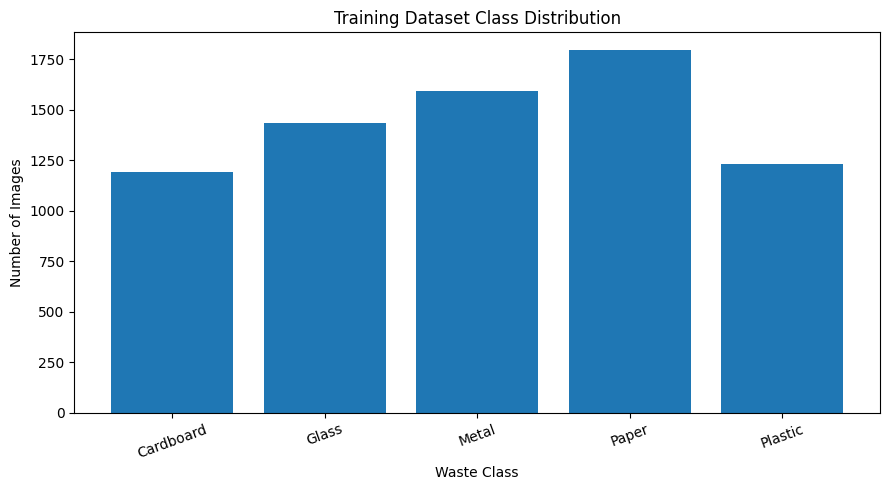


Report saved:
/kaggle/working/Final_Waste_Dataset/research_metadata/training_class_balance.csv


In [81]:
# ============================================================
# STEP 16 — FINAL CLASS BALANCE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("FINAL TRAINING CLASS BALANCE ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Class counts
# ------------------------------------------------------------

class_counts = (
    train_df["class"]
    .value_counts()
    .reindex(classes)
)

class_percentages = (
    class_counts /
    class_counts.sum() *
    100
)

balance_df = pd.DataFrame({
    "class": classes,
    "count": class_counts.values,
    "percentage": class_percentages.values
})

print(balance_df.to_string(index=False))

# ------------------------------------------------------------
# Imbalance statistics
# ------------------------------------------------------------

max_count = class_counts.max()
min_count = class_counts.min()

imbalance_ratio = (
    max_count /
    min_count
)

print("\n" + "-" * 80)

print(
    f"Maximum class count : {max_count:,}"
)

print(
    f"Minimum class count : {min_count:,}"
)

print(
    f"Imbalance ratio     : {imbalance_ratio:.4f}"
)

# ------------------------------------------------------------
# Inverse-frequency class weights
# ------------------------------------------------------------

weights = (
    len(train_df) /
    (
        len(classes) *
        class_counts.values
    )
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
)

print("\n" + "-" * 80)
print("CLASS WEIGHTS")

for cls, weight in zip(
    classes,
    class_weights
):

    print(
        f"{cls:<12}: {weight:.4f}"
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    balance_df["class"],
    balance_df["count"]
)

plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.title(
    "Training Dataset Class Distribution"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Save report
# ------------------------------------------------------------

balance_report = (
    METADATA_ROOT /
    "training_class_balance.csv"
)

balance_df.to_csv(
    balance_report,
    index=False
)

print(
    "\nReport saved:"
)

print(
    balance_report
)

# ## # # #  আজকের কাজের জন্য একটি FINAL CHECKPOINT cell 

In [82]:
# ============================================================
# FINAL CHECKPOINT — DO NOT MODIFY DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import json
from datetime import datetime

BASE = Path("/kaggle/working/Final_Waste_Dataset")
META = BASE / "research_metadata"

checkpoint = {
    "checkpoint_name": "FINAL_DATASET_AUDIT_COMPLETE",
    "created_at": datetime.now().isoformat(),

    "dataset": {
        "final_metadata": 10668,
        "train": 7246,
        "validation": 1550,
        "test": 1872,
        "bangladesh_test": 318,
        "international_test": 1289
    },

    "quality": {
        "removed_images": 22,
        "train_validation_leakage": 0,
        "train_test_leakage": 0,
        "validation_test_leakage": 0,
        "internal_duplicates": 0
    },

    "pipeline": {
        "framework": "PyTorch",
        "image_size": "224x224",
        "batch_size": 32,
        "workers": 2,
        "num_classes": 5
    },

    "class_mapping": {
        "Cardboard": 0,
        "Glass": 1,
        "Metal": 2,
        "Paper": 3,
        "Plastic": 4
    },

    "training_balance": {
        "Cardboard": 1193,
        "Glass": 1433,
        "Metal": 1594,
        "Paper": 1793,
        "Plastic": 1233
    },

    "class_weights": {
        "Cardboard": 1.2148,
        "Glass": 1.0113,
        "Metal": 0.9092,
        "Paper": 0.8083,
        "Plastic": 1.1753
    }
}

checkpoint_path = META / "FINAL_CHECKPOINT.json"

with open(checkpoint_path, "w", encoding="utf-8") as f:
    json.dump(
        checkpoint,
        f,
        indent=4,
        ensure_ascii=False
    )

print("=" * 80)
print("FINAL RESEARCH CHECKPOINT CREATED")
print("=" * 80)

print("Checkpoint:", checkpoint_path)
print()
print("Dataset:")
for k, v in checkpoint["dataset"].items():
    print(f"{k:<25}: {v:,}")

print()
print("Quality:")
for k, v in checkpoint["quality"].items():
    print(f"{k:<30}: {v}")

print()
print("✓ DATASET STATE FROZEN")
print("✓ NO IMAGE COPYING")
print("✓ NO IMAGE DELETION")
print("✓ METADATA PRESERVED")
print("✓ READY TO RESUME TRAINING")

FINAL RESEARCH CHECKPOINT CREATED
Checkpoint: /kaggle/working/Final_Waste_Dataset/research_metadata/FINAL_CHECKPOINT.json

Dataset:
final_metadata           : 10,668
train                    : 7,246
validation               : 1,550
test                     : 1,872
bangladesh_test          : 318
international_test       : 1,289

Quality:
removed_images                : 22
train_validation_leakage      : 0
train_test_leakage            : 0
validation_test_leakage       : 0
internal_duplicates           : 0

✓ DATASET STATE FROZEN
✓ NO IMAGE COPYING
✓ NO IMAGE DELETION
✓ METADATA PRESERVED
✓ READY TO RESUME TRAINING


# ## # #  FINAL RESEARCH PACKAGE — METADATA ONLY

In [83]:
# ============================================================
# FINAL RESEARCH PACKAGE — METADATA ONLY
# ============================================================

from pathlib import Path
import shutil
import json
from datetime import datetime

SOURCE = Path("/kaggle/working/Final_Waste_Dataset/research_metadata")

PACKAGE = Path("/kaggle/working/Waste_Dataset_Research_Metadata")

# Clean old package if it exists
if PACKAGE.exists():
    shutil.rmtree(PACKAGE)

PACKAGE.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Files to preserve
# ------------------------------------------------------------

files_to_save = [
    "final_metadata.csv",
    "train_final.csv",
    "validation_final.csv",
    "test_final.csv",
    "test_bangladesh_final.csv",
    "test_international_final.csv",
    "manual_review_decisions.csv",
    "training_class_balance.csv",
]

copied = []

for filename in files_to_save:

    source = SOURCE / filename
    destination = PACKAGE / filename

    if source.exists():

        shutil.copy2(source, destination)
        copied.append(filename)

        print("✓", filename)

    else:

        print("⚠ NOT FOUND:", filename)

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------

config = {
    "dataset_name": "Bangladesh_International_Waste_Classification",
    "version": "v1.0_final_audited",

    "created_at": datetime.now().isoformat(),

    "total_images": 10668,

    "splits": {
        "train": 7246,
        "validation": 1550,
        "test": 1872,
        "test_bangladesh": 318,
        "test_international": 1289
    },

    "removed_images": 22,

    "class_mapping": {
        "Cardboard": 0,
        "Glass": 1,
        "Metal": 2,
        "Paper": 3,
        "Plastic": 4
    },

    "pipeline": {
        "framework": "PyTorch",
        "image_size": [224, 224],
        "batch_size": 32,
        "workers": 2
    },

    "quality": {
        "train_validation_leakage": 0,
        "train_test_leakage": 0,
        "validation_test_leakage": 0,
        "internal_duplicates": 0
    },

    "files": copied
}

with open(
    PACKAGE / "dataset_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        indent=4,
        ensure_ascii=False
    )

print("\n" + "=" * 80)
print("FINAL PACKAGE READY")
print("=" * 80)

print(PACKAGE)

print("\nFiles:")

for file in sorted(PACKAGE.iterdir()):

    print(
        f"{file.name:<40}"
        f"{file.stat().st_size / 1024:.1f} KB"
    )

✓ final_metadata.csv
✓ train_final.csv
✓ validation_final.csv
✓ test_final.csv
✓ test_bangladesh_final.csv
✓ test_international_final.csv
✓ manual_review_decisions.csv
✓ training_class_balance.csv

FINAL PACKAGE READY
/kaggle/working/Waste_Dataset_Research_Metadata

Files:
dataset_config.json                     1.1 KB
final_metadata.csv                      2020.0 KB
manual_review_decisions.csv             7.2 KB
test_bangladesh_final.csv               64.5 KB
test_final.csv                          356.4 KB
test_international_final.csv            238.9 KB
train_final.csv                         1370.4 KB
training_class_balance.csv              0.2 KB
validation_final.csv                    293.3 KB


In [84]:
# ============================================================
# CREATE FINAL RESEARCH CHECKPOINT ZIP
# ============================================================

from pathlib import Path
import zipfile
import os

SOURCE = Path(
    "/kaggle/working/Final_Waste_Dataset/research_metadata"
)

OUTPUT = Path(
    "/kaggle/working/final_waste_research_metadata_v1.0.zip"
)

FILES = [
    "final_metadata.csv",
    "train_final.csv",
    "validation_final.csv",
    "test_final.csv",
    "test_bangladesh_final.csv",
    "test_international_final.csv",
    "manual_review_decisions.csv",
    "training_class_balance.csv",
    "FINAL_CHECKPOINT.json",
]

# Remove old zip if exists
if OUTPUT.exists():
    OUTPUT.unlink()

with zipfile.ZipFile(
    OUTPUT,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for filename in FILES:

        path = SOURCE / filename

        if path.exists():

            z.write(
                path,
                arcname=filename
            )

            print("✓ Added:", filename)

        else:

            print("⚠ Missing:", filename)

print("\n" + "=" * 80)
print("CHECKPOINT ZIP CREATED")
print("=" * 80)

print("Path:", OUTPUT)

size_mb = OUTPUT.stat().st_size / (1024 * 1024)

print(
    f"Size: {size_mb:.2f} MB"
)

✓ Added: final_metadata.csv
✓ Added: train_final.csv
✓ Added: validation_final.csv
✓ Added: test_final.csv
✓ Added: test_bangladesh_final.csv
✓ Added: test_international_final.csv
✓ Added: manual_review_decisions.csv
✓ Added: training_class_balance.csv
✓ Added: FINAL_CHECKPOINT.json

CHECKPOINT ZIP CREATED
Path: /kaggle/working/final_waste_research_metadata_v1.0.zip
Size: 0.23 MB


In [85]:
import zipfile

ZIP_PATH = "/kaggle/working/final_waste_research_metadata_v1.0.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    print("=" * 80)
    print("ZIP CONTENT")
    print("=" * 80)

    for name in z.namelist():
        print("✓", name)

    print("\nZIP VALID:",
          z.testzip() is None)

ZIP CONTENT
✓ final_metadata.csv
✓ train_final.csv
✓ validation_final.csv
✓ test_final.csv
✓ test_bangladesh_final.csv
✓ test_international_final.csv
✓ manual_review_decisions.csv
✓ training_class_balance.csv
✓ FINAL_CHECKPOINT.json

ZIP VALID: True


In [86]:
# ============================================================
# RESUME CHECKPOINT — STORAGE + FILES
# ============================================================

from pathlib import Path
import shutil
import os

print("=" * 80)
print("RESUME CHECKPOINT")
print("=" * 80)

# ------------------------------------------------------------
# Disk
# ------------------------------------------------------------

total, used, free = shutil.disk_usage("/kaggle/working")

print("\nKAGGLE STORAGE")

print(
    f"Total : {total / (1024**3):.2f} GB"
)

print(
    f"Used  : {used / (1024**3):.2f} GB"
)

print(
    f"Free  : {free / (1024**3):.2f} GB"
)

# ------------------------------------------------------------
# Important directories
# ------------------------------------------------------------

paths = [
    "/kaggle/working/Final_Waste_Dataset",
    "/kaggle/working/Final_Waste_Dataset/research_metadata",
]

print("\nIMPORTANT PATHS")

for p in paths:

    path = Path(p)

    if path.exists():
        print("✓ EXISTS:", p)
    else:
        print("✗ NOT FOUND:", p)

RESUME CHECKPOINT

KAGGLE STORAGE
Total : 19.52 GB
Used  : 17.89 GB
Free  : 1.61 GB

IMPORTANT PATHS
✓ EXISTS: /kaggle/working/Final_Waste_Dataset
✓ EXISTS: /kaggle/working/Final_Waste_Dataset/research_metadata


In [87]:
import numpy as np
import pandas as pd

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    ...